# Trabajo Práctico 3

# 1. Setup e importación de datos

In [1]:
# Instalación de librerías necesarias
# pip install scikit-learn prince geopandas scipy matplotlib seaborn geopy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import requests
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

# Prince (MCA)
import prince

# Scipy
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency, spearmanr
from scipy.spatial.distance import cdist

# Configuración general de los gráficos y de pandas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_columns', None)
SEED = 42

### 1.1 Carga del dataset enriquecido con coordenadas

Cargamos el dataset que ya viene con las coordenadas calculadas. Para cada propiedad agregamos la latitud, la longitud y la fuente que se usó para resolver la dirección. Las coordenadas surgen del consenso entre dos APIs oficiales argentinas que corrimos sobre las direcciones únicas de la base.

Hay un detalle importante: aproximadamente uno de cada siete avisos no tiene coordenadas. Esto pasa cuando el aviso no incluye calle y altura, o cuando la dirección quedó como texto libre (por ejemplo, descripciones del estilo "Venta departamento en Recoleta"). Esos avisos quedan en la base para los análisis que no necesitan geografía, pero los sacamos de cualquier cálculo de distancia o de agrupamiento espacial.

In [3]:
df = pd.read_csv('../data/geocoding/dataframe_con_coords.tsv', sep='\t', low_memory=False)
print(f'Dataset cargado: {df.shape[0]:,} filas y {df.shape[1]} columnas')
print(f'Con coordenadas: {df["lat"].notna().sum():,} '
      f'({100 * df["lat"].notna().mean():.1f} %)')
df.head()

Dataset cargado: 51,996 filas y 51 columnas
Con coordenadas: 44,142 (84.9 %)


,posting_id,sitio,operacion,precio,calle,altura,losa_central,aire_acond,apto_credito,cochera,seguridad,luminoso,balcon_aterrazado,barrio_oficial,moneda,accesible_movilidad_reducida,acepta_caucion,agua_caliente_central,ambientes,antiguedad_años,apto_profesional,ascensor,balcon,baulera,baños,dependencia_servicio,dormitorios,expensas_incluidas_en_precio,gimnasio,lavadero,m2_total,ofrece_financiacion,parrilla,pileta,portero,sum,terraza,tiene_expensas,expensas,sobre_avenida,precio_por_m2,segmento_zona,segmento_zona_modelo,log_precio,log_m2,log_precio_m2,amenities_count,m2_relativo_barrio,lat,lon,geo_source
0,58757240,zonaprop,alquiler,"750,000.000",Mansilla,"2,936.000",0,0,0,0,0,1,0,Recoleta,ars,0,0,0,2.000,36.000,0,0,1,0,1.000,0,1.000,False,0,1,60.000,0,0,0,0,0,1,1.000,"300,000.000",0,"12,500.000",estandar,estandar,13.528,4.111,9.434,5.000,NaN,-34.595,-58.408,consenso_multi_api
1,58818211,zonaprop,alquiler,"1,700,000.000",Cespedes,"2,300.000",0,0,0,1,0,0,0,Belgrano,ars,0,1,0,3.000,35.000,0,0,1,0,2.000,0,2.000,False,0,1,114.000,0,1,0,0,0,1,1.000,"400,000.000",0,"14,912.281",estandar,estandar,14.346,4.745,9.610,7.000,NaN,-34.568,-58.447,consenso_multi_api
2,58564550,zonaprop,alquiler,"2,500.000",Riobamba,"1,200.000",0,0,0,1,1,1,0,Recoleta,usd,0,0,0,4.000,48.500,0,0,1,0,2.000,0,2.000,False,1,1,121.000,0,1,1,0,0,0,1.000,"1,150,000.000",0,20.661,estandar,estandar,7.824,4.804,3.076,9.000,NaN,-34.595,-58.395,consenso_multi_api
3,58314210,zonaprop,alquiler,"1,300.000",Pereyra Lucena,"2,500.000",0,0,0,1,0,1,1,Palermo,usd,0,0,0,2.000,20.000,1,0,1,0,1.000,0,1.000,False,0,0,66.000,0,0,0,0,0,1,1.000,"384,500.000",0,19.697,estandar,estandar,7.171,4.205,3.030,7.000,NaN,NaN,NaN,consenso_multi_api
4,58810878,zonaprop,alquiler,"3,800.000",Lola Mora,400.000,0,0,0,1,1,0,0,Puerto Madero,usd,0,0,0,3.000,14.000,0,0,0,0,2.000,0,2.000,False,1,0,117.000,0,0,1,0,0,0,1.000,"507,000.000",0,32.479,premium,premium,8.243,4.771,3.511,5.000,NaN,NaN,NaN,consenso_multi_api


In [4]:
# Revisamos rápidamente las columnas y la distribución por tipo de operación
print('Columnas disponibles:')
print(df.columns.tolist())
print('\nDistribución por operación:')
print(df['operacion'].value_counts())

Columnas disponibles:
['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura', 'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'ambientes', 'antiguedad_años', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños', 'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas', 'sobre_avenida', 'precio_por_m2', 'segmento_zona', 'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2', 'amenities_count', 'm2_relativo_barrio', 'lat', 'lon', 'geo_source']

Distribución por operación:
operacion
venta                28643
alquiler             18220
alquiler_temporal     5133
Name: count, dtype: int64


También importamos los KPIs que calculamos en la entrega anterior.

In [5]:
# TODO: ver con cual nos quedamos, son un poco distintos. No se como se crea el df_kpis_barrio en eda, asi que no lo pude pasar al 04_kpi_pipeline (en raw esta el de eda, en processed el de 04_kpi_pipeline)

df_kpis = pd.read_csv('../data/processed/dataframe_kpis.tsv', sep='\t')
print(f'Dataset cargado: {df_kpis.shape[0]:,} filas y {df_kpis.shape[1]} columnas')
df_kpis.head()

Dataset cargado: 48 filas y 22 columnas


,barrio_oficial,venta_mediana,alquiler_mediano,expensas_medianas,tarifa_mensual_mediana,precio_m2_mediano,rent_bruta_lp_pct,rent_neta_lp_pct,rent_bruta_temp_pct,rent_neta_temp_pct,años_recupero,retorno_neto_lp_mediano,retorno_neto_temp_mediano,ingreso_anual_mediano,costo_propietario_mediano,costo_expensas_pct,indice_bruto,indice_neto,modalidad_optima_bruta,modalidad_optima_neta,n_lp,n_temp
0,Villa Luro,"119,450.000",494.700,91.873,"1,300.000","2,414.286",4.970,5,9.530,9.000,20.100,"5,936.396","10,158.318","11,388.000","1,229.682",1.000,1.920,1.800,Temporario,Temporario,157,2.000
1,Nueva Pompeya,"75,000.000",494.700,70.671,925.000,"1,333.333",7.920,7,10.800,9.000,12.600,"5,512.367","6,958.124","8,103.000","1,144.876",2.000,1.360,1.290,Temporario,Temporario,17,2.000
2,Parque Avellaneda,"78,000.000",459.364,77.739,"1,000.000","1,612.903",7.070,7,11.230,7.000,14.100,"5,512.367","5,791.802","8,760.000","2,968.198",4.000,1.590,1.000,Temporario,Largo plazo,40,1.000
3,La Boca,"73,640.000",416.961,100.707,600.000,"1,393.023",6.790,7,7.140,6.000,14.700,"5,003.534","4,323.138","5,256.000","1,017.668",1.000,1.050,0.860,Temporario,Largo plazo,70,4.000
4,Monserrat,"87,000.000",500.000,134.276,600.000,"1,828.571",6.900,7,6.040,5.000,14.500,"6,000.000","4,139.555","5,256.000","1,526.502",2.000,0.880,0.710,Largo plazo,Largo plazo,329,123.000


In [6]:
df_kpis = pd.read_csv('../data/raw/dataframe_kpis.tsv', sep='\t')
print(f'Dataset cargado: {df_kpis.shape[0]:,} filas y {df_kpis.shape[1]} columnas')
df_kpis.head()

Dataset cargado: 48 filas y 18 columnas


,barrio_oficial,rent_bruta_lp_pct,años_recupero,precio_m2_mediano,precio_m2_promedio,retorno_neto_lp_mediano,rent_neta_lp_pct,m2_relativo_barrio_mediano,rent_bruta_temp_pct,indice_bruto,modalidad_optima_bruta,ingreso_anual_mediano,costo_propietario_mediano,retorno_neto_temp_mediano,costo_expensas_pct,rent_neta_temp_pct,indice_neto,modalidad_optima_neta
0,Agronomia,5.140,19.500,"2,375.000","2,452.000","5,088.339",5,1.000,5.310,1.030,Temporario,"5,256.000","1,187.279","4,068.721",1.000,4.000,0.800,Largo plazo
1,Almagro,4.550,22.000,"2,297.000","2,352.000","5,681.979",5,1.000,4.560,1.000,Temporario,"5,694.000","1,187.279","4,407.943",1.000,4.000,0.800,Largo plazo
2,Balvanera,6.120,16.300,"1,645.000","1,731.000","5,512.367",6,1.000,5.570,0.910,Largo plazo,"5,014.558","1,297.527","3,559.887",1.000,4.000,0.670,Largo plazo
3,Barracas,5.300,18.900,"2,091.000","2,160.000","6,614.841",5,1.000,4.960,0.940,Largo plazo,"6,190.813","1,653.710","4,690.304",1.000,4.000,0.800,Largo plazo
4,Belgrano,4.240,23.600,"3,112.000","3,351.000","9,328.622",4,1.000,3.240,0.760,Largo plazo,"7,119.435","1,526.502","5,502.700",1.000,3.000,0.750,Largo plazo


In [7]:
df_kpis.columns

Index(['barrio_oficial', 'rent_bruta_lp_pct', 'años_recupero',
       'precio_m2_mediano', 'precio_m2_promedio', 'retorno_neto_lp_mediano',
       'rent_neta_lp_pct', 'm2_relativo_barrio_mediano', 'rent_bruta_temp_pct',
       'indice_bruto', 'modalidad_optima_bruta', 'ingreso_anual_mediano',
       'costo_propietario_mediano', 'retorno_neto_temp_mediano',
       'costo_expensas_pct', 'rent_neta_temp_pct', 'indice_neto',
       'modalidad_optima_neta'],
      dtype='str')

### 1.2 Preparación para análisis

Aunque al principio nos resultaron útiles, decidimos descartar las pocas ventas que están publicadas en pesos. Aún convirtiéndolas a dólares quedaban en valores muy bajos por las condiciones particulares de esas propiedades (en general en mal estado), y nos generaban ruido en las conclusiones.

In [8]:
df = df[~((df['operacion'] == 'venta') & (df['moneda'] == 'ars'))]

In [9]:
resumen_moneda = df.groupby(["moneda", "operacion"])["precio"].agg(["count","mean", "median", "std", "min", "max"])
resumen_moneda

count        mean      median         std  \
moneda operacion                                                      
ars    alquiler           12339 803,925.003 700,000.000 359,879.307   
       alquiler_temporal    459 784,724.887 750,000.000 253,418.624   
usd    alquiler            5881   1,713.305   1,200.000   1,431.851   
       alquiler_temporal   4674   1,052.809     800.000     667.782   
       venta              28639 237,102.007 145,000.000 346,399.372   

                                 min           max  
moneda operacion                                    
ars    alquiler          115,000.000 4,500,000.000  
       alquiler_temporal 120,000.000 2,000,000.000  
usd    alquiler              300.000    10,000.000  
       alquiler_temporal     250.000     5,000.000  
       venta              24,000.000 9,500,000.000

Para poder comparar todos los precios entre sí, sumamos una columna con los valores convertidos a dólares.

In [10]:
from datetime import date
import requests

def obtener_dolar_oficial():
    hoy = date.today().strftime("%Y-%m-%d")

    try:
        url = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=1&sort=desc"
        r = requests.get(url, timeout=10)
        r.raise_for_status()
        tc = r.json()['data'][0][1]
        print(f"[datos.gob.ar] Dólar oficial al {hoy}: $ {tc:,.2f} ARS/USD")
        return tc
    except Exception as e:
        print(f"datos.gob.ar falló: {e}")

    print("\nNo se pudo obtener el tipo de cambio.")
    print("  Ingresalo manualmente en la siguiente línea:")
    return None

TIPO_DE_CAMBIO_USD = obtener_dolar_oficial()

df['precio_usd'] = df.apply(lambda row: row['precio'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio'], axis=1)
df['precio_por_m2_usd'] = df.apply(lambda row: row['precio_por_m2'] / TIPO_DE_CAMBIO_USD if row['moneda'] == 'ars' else row['precio_por_m2'], axis=1)
print("Precios convertidos a dólares usando el tipo de cambio oficial.")

[datos.gob.ar] Dólar oficial al 2026-06-01: $ 1,415.00 ARS/USD
Precios convertidos a dólares usando el tipo de cambio oficial.


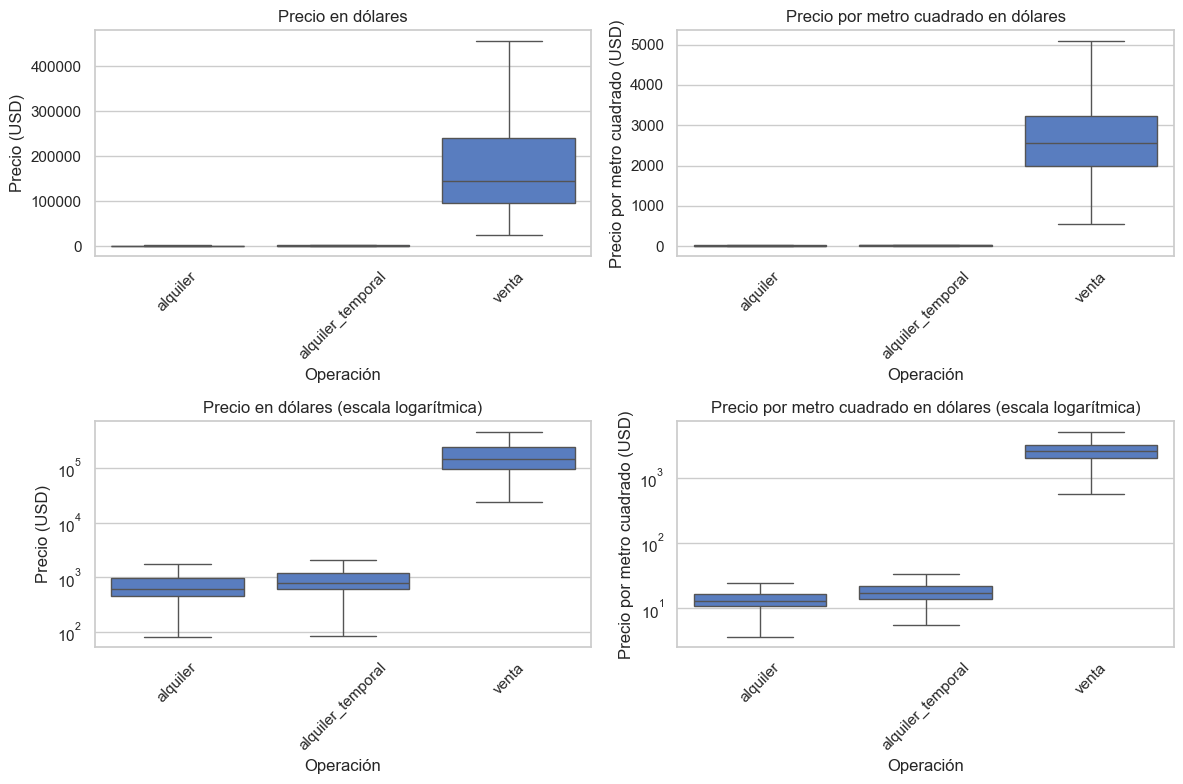

In [11]:
df_box_precio = df.dropna(subset=["operacion", "precio_usd"]).copy()
df_box_m2 = df.dropna(subset=["operacion", "precio_por_m2_usd"]).copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Precio en dólares
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[0, 0])
axes[0, 0].set_title("Precio en dólares")
axes[0, 0].set_xlabel("Operación")
axes[0, 0].set_ylabel("Precio (USD)")
axes[0, 0].tick_params(axis="x", rotation=45)

# Precio por metro cuadrado en dólares
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[0, 1])
axes[0, 1].set_title("Precio por metro cuadrado en dólares")
axes[0, 1].set_xlabel("Operación")
axes[0, 1].set_ylabel("Precio por metro cuadrado (USD)")
axes[0, 1].tick_params(axis="x", rotation=45)

# Precio en dólares, escala logarítmica
sns.boxplot(data=df_box_precio, x="operacion", y="precio_usd", showfliers=False, ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Precio en dólares (escala logarítmica)")
axes[1, 0].set_xlabel("Operación")
axes[1, 0].set_ylabel("Precio (USD)")
axes[1, 0].tick_params(axis="x", rotation=45)

# Precio por metro cuadrado en dólares, escala logarítmica
sns.boxplot(data=df_box_m2, x="operacion", y="precio_por_m2_usd", showfliers=False, ax=axes[1, 1])
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("Precio por metro cuadrado en dólares (escala logarítmica)")
axes[1, 1].set_xlabel("Operación")
axes[1, 1].set_ylabel("Precio por metro cuadrado (USD)")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# 2. Enriquecimiento espacial

Esto nos sirve para testear la hipótesis de que la cercanía al subte impacta en el precio del metro cuadrado, y también lo aprovechamos más adelante en el clustering y en los modelos.

Como ya mencionamos, las propiedades que no tienen coordenadas no entran en ninguno de los cálculos espaciales. Sí las seguimos usando para los análisis que no dependen de la ubicación.

### 2.1 Descarga de fuentes exógenas

Arrancamos bajando las coordenadas de las estaciones de subte para poder medir qué tan cerca está cada propiedad de la red.

In [12]:
URL_SUBTE = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/sbase/'
    'subte-estaciones/estaciones-de-subte.csv'
)

subte = pd.read_csv(URL_SUBTE, sep=';')
print('Columnas del CSV de subte:', subte.columns.tolist())
subte.head(3)

Columnas del CSV de subte: ['long', 'lat', 'id', 'estacion', 'linea']


,long,lat,id,estacion,linea
0,"-58,39892759","-34,63575018",1,CASEROS,H
1,"-58,40096956","-34,62937566",2,INCLAN - MEZQUITA AL AHMAD,H
2,"-58,40232273","-34,62309232",3,HUMBERTO 1Â°,H


In [13]:
subte.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   long      90 non-null     str  
 1   lat       90 non-null     str  
 2   id        90 non-null     int64
 3   estacion  90 non-null     str  
 4   linea     90 non-null     str  
dtypes: int64(1), str(4)
memory usage: 3.6 KB


In [14]:
col_map = {}
for col in subte.columns:
    cl = col.lower()
    if 'lat' in cl:
        col_map[col] = 'lat_subte'
    elif 'long' in cl:
        col_map[col] = 'lon_subte'
    elif 'nombre' in cl or 'estacion' in cl or 'station' in cl:
        col_map[col] = 'nombre_estacion'
    elif 'linea' in cl or 'line' in cl:
        col_map[col] = 'linea'

subte = subte.rename(columns=col_map)
subte = subte[['lon_subte', 'lat_subte']].dropna()
# En el archivo original las comas hacen de separador decimal, las cambiamos por punto
subte['lat_subte'] = subte['lat_subte'].str.replace(',', '.', regex=False)
subte['lon_subte'] = subte['lon_subte'].str.replace(',', '.', regex=False)
subte['lat_subte'] = pd.to_numeric(subte['lat_subte'])
subte['lon_subte'] = pd.to_numeric(subte['lon_subte'])
subte = subte.dropna()
print(f'Estaciones de subte disponibles: {len(subte)}')
subte.head()

Estaciones de subte disponibles: 90


,lon_subte,lat_subte
0,-58.399,-34.636
1,-58.401,-34.629
2,-58.402,-34.623
3,-58.405,-34.615
4,-58.406,-34.609


### 2.2 Cobertura del geocoding por barrio

Antes de seguir, revisamos qué tan bien resolvieron las coordenadas en cada barrio. Esto nos sirve para tener en mente dónde puede haber sesgo por menor cobertura.

In [15]:
# Cuántas propiedades quedaron con coordenadas usables
mask_geo = df['lat'].notna() & df['lon'].notna()
print(f'Total de avisos:                   {len(df):>7,}')
print(f'Con coordenadas (uso geográfico):  {mask_geo.sum():>7,}  ({100*mask_geo.mean():.1f} %)')
print(f'Sin coordenadas (quedan fuera):    {(~mask_geo).sum():>7,}')

cob = (df.groupby('barrio_oficial')
         .agg(total=('lat', 'size'), con_coords=('lat', 'count'))
         .assign(cobertura_pct=lambda x: (100 * x['con_coords'] / x['total']).round(1)))

print('\nBarrios con menor cobertura, donde más avisos quedaron sin coordenadas:')
print(cob.sort_values('cobertura_pct').head(5).to_string())
print('\nBarrios con mejor cobertura:')
print(cob.sort_values('cobertura_pct', ascending=False).head(5).to_string())

Total de avisos:                    51,992
Con coordenadas (uso geográfico):   44,138  (84.9 %)
Sin coordenadas (quedan fuera):      7,854

Barrios con menor cobertura, donde más avisos quedaron sin coordenadas:
                   total  con_coords  cobertura_pct
barrio_oficial                                     
Puerto Madero       1764        1201         68.100
Villa Lugano         276         199         72.100
Villa Soldati         20          15         75.000
Agronomia             70          53         75.700
Parque Avellaneda    118          91         77.100

Barrios con mejor cobertura:
                total  con_coords  cobertura_pct
barrio_oficial                                  
Villa Ortuzar     220         210         95.500
Constitucion      259         246         95.000
San Cristobal     714         670         93.800
Coghlan           369         338         91.600
Mataderos         248         227         91.500


Como podemos ver, en general obtuvimos una gran cantidad de cobertura de coordenadas. Puerto Madero es el barrio con menor cobertura (68%). Consecuentemente, consideramos que tenemos suficientes coordenadas para realizar análisis de distancias robustas.

In [16]:
# Bajamos el GeoJSON con los polígonos de los barrios de CABA
URL_GEOJSON = (
    'https://cdn.buenosaires.gob.ar/datosabiertos/datasets/'
    'ministerio-de-educacion/barrios/barrios.geojson'
)
gdf_barrios = gpd.read_file(URL_GEOJSON)

# Normalizamos el nombre de la columna que tiene el barrio
for col in gdf_barrios.columns:
    if 'nombre' in col.lower():
        gdf_barrios = gdf_barrios.rename(columns={col: 'barrio_oficial'})
        break

# Calculamos el centroide de cada barrio
gdf_barrios = gdf_barrios.set_crs('EPSG:4326', allow_override=True)
gdf_barrios['centroid'] = gdf_barrios.geometry.centroid
gdf_barrios['lat_barrio'] = gdf_barrios['centroid'].y
gdf_barrios['lon_barrio'] = gdf_barrios['centroid'].x

centroides = gdf_barrios[['barrio_oficial', 'lat_barrio', 'lon_barrio']].copy()
print(f'Barrios con centroide calculado: {len(centroides)}')
centroides.head()

Barrios con centroide calculado: 48


,barrio_oficial,lat_barrio,lon_barrio
0,Agronomia,-34.593,-58.489
1,Almagro,-34.609,-58.422
2,Balvanera,-34.609,-58.403
3,Barracas,-34.646,-58.384
4,Belgrano,-34.555,-58.450


### 2.3 Cálculo de distancia al subte más cercano

Usamos la distancia euclidiana en grados como aproximación, corregida por el factor de latitud. Para la ciudad de Buenos Aires un grado de latitud equivale a unos 111 kilómetros, y un grado de longitud a unos 91. Con esa conversión simple podemos pasar los grados a kilómetros sin complicarnos.

In [17]:
def distancia_min_subte_km(lat, lon, subte_coords):
    """Distancia en kilómetros al subte más cercano para un punto.
    Es una aproximación euclidiana corregida por latitud, válida
    para distancias cortas dentro de la ciudad."""
    LAT_KM = 111.0
    LON_KM = 111.0 * np.cos(np.radians(lat))
    dlat = (subte_coords[:, 0] - lat) * LAT_KM
    dlon = (subte_coords[:, 1] - lon) * LON_KM
    return np.sqrt(dlat ** 2 + dlon ** 2).min()


def distancia_min_subte_km_vec(lats, lons, subte_coords):
    """Versión vectorizada. Recibe arrays de latitudes y longitudes
    y devuelve un array con las distancias mínimas. Donde la coordenada
    de entrada es nula, devuelve nulo."""
    lats = np.asarray(lats, dtype=float)
    lons = np.asarray(lons, dtype=float)
    out = np.full(len(lats), np.nan)
    valid = ~(np.isnan(lats) | np.isnan(lons))
    if not valid.any():
        return out
    lv, ov = lats[valid], lons[valid]
    lat_km = 111.0
    lon_km = 111.0 * np.cos(np.radians(lv[:, None]))
    dlat = (subte_coords[:, 0][None, :] - lv[:, None]) * lat_km
    dlon = (subte_coords[:, 1][None, :] - ov[:, None]) * lon_km
    out[valid] = np.sqrt(dlat ** 2 + dlon ** 2).min(axis=1)
    return out


subte_coords = subte[['lat_subte', 'lon_subte']].values

# También calculamos la distancia desde el centroide de cada barrio,
# que nos sirve como referencia y para los mapas coropléticos
centroides['dist_subte_km_centroide'] = centroides.apply(
    lambda row: distancia_min_subte_km(row['lat_barrio'], row['lon_barrio'], subte_coords),
    axis=1
)
print('Distancia desde el centroide al subte más cercano, por barrio. Los más cercanos y los más lejanos:')
ordenado = centroides[['barrio_oficial', 'dist_subte_km_centroide']].sort_values('dist_subte_km_centroide')
print(pd.concat([ordenado.head(5), ordenado.tail(5)]).to_string(index=False))

Distancia desde el centroide al subte más cercano, por barrio. Los más cercanos y los más lejanos:
 barrio_oficial  dist_subte_km_centroide
    San Nicolas                    0.018
      Monserrat                    0.073
  San Cristobal                    0.094
      Chacarita                    0.151
      Balvanera                    0.188
      Mataderos                    4.023
        Liniers                    4.747
      Versalles                    4.821
     Villa Real                    5.300
Villa Riachuelo                    5.391


In [18]:
# Calculamos la distancia al subte para cada propiedad
df['dist_subte_km'] = distancia_min_subte_km_vec(df['lat'].values, df['lon'].values, subte_coords)

# Sumamos las coordenadas del centroide del barrio, que después usamos en algunos mapas
df = df.merge(centroides[['barrio_oficial', 'lat_barrio', 'lon_barrio']],
              on='barrio_oficial', how='left')

mask = df['dist_subte_km'].notna()
print(f'Propiedades con distancia al subte calculada: {mask.sum():,} de {len(df):,} '
      f'({100*mask.mean():.1f} %)')
print(f'Excluidas del análisis geográfico (sin coordenadas): {(~mask).sum():,}')
print('\nEstadísticas de la distancia al subte en kilómetros, solo para las propiedades con coordenadas:')
print(df['dist_subte_km'].describe())

Propiedades con distancia al subte calculada: 44,138 de 51,992 (84.9 %)
Excluidas del análisis geográfico (sin coordenadas): 7,854

Estadísticas de la distancia al subte en kilómetros, solo para las propiedades con coordenadas:
count   44,138.000
mean         0.846
std          0.939
min          0.001
25%          0.303
50%          0.533
75%          0.929
max          5.794
Name: dist_subte_km, dtype: float64


### 2.4 Visualización espacial: precio por metro cuadrado y distancia al subte

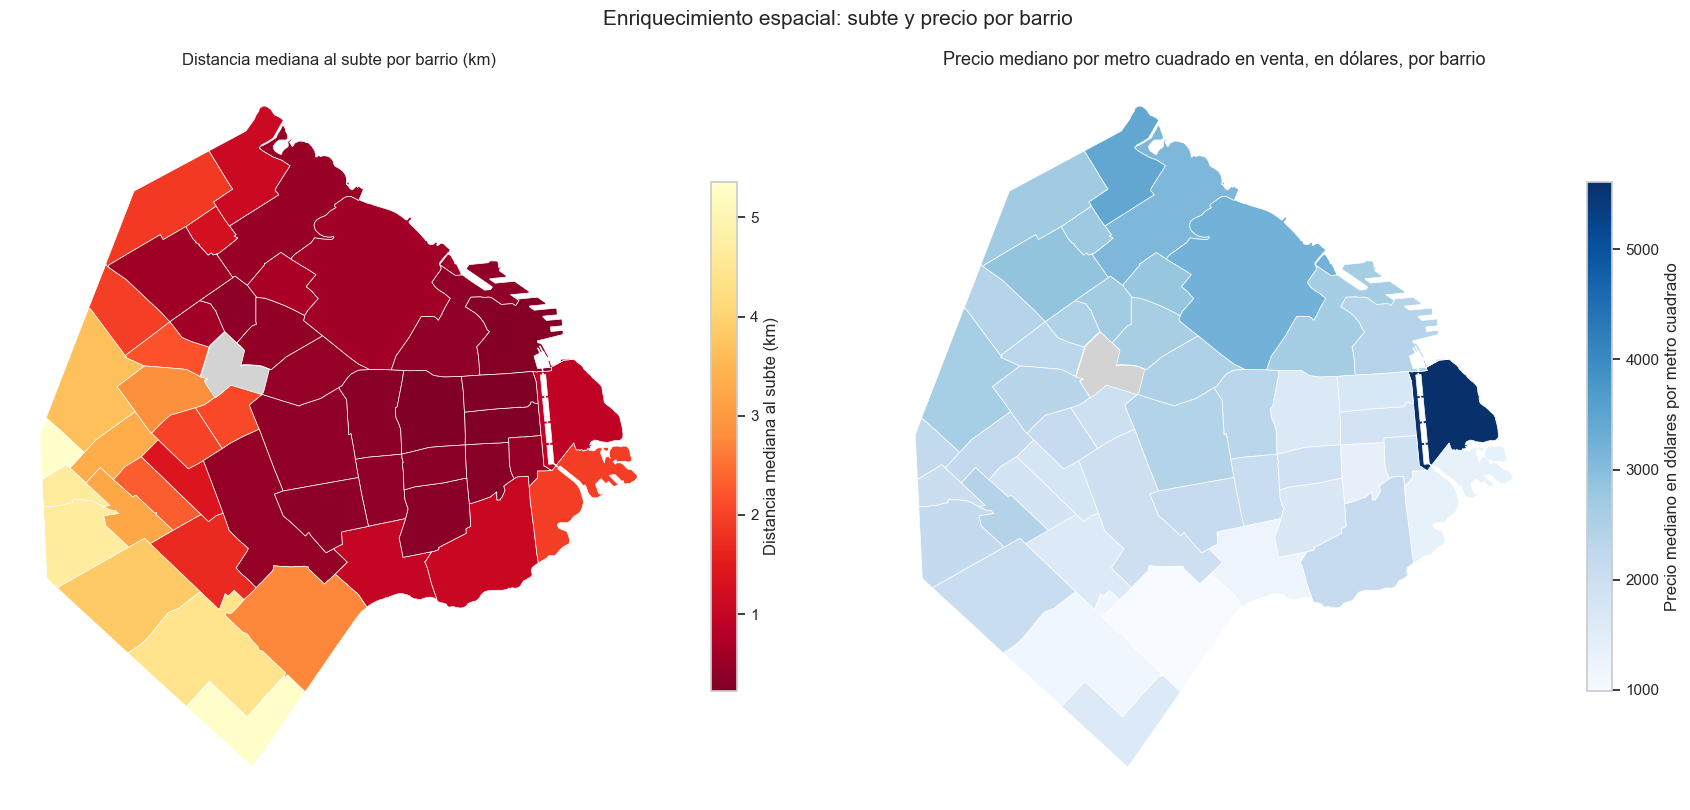

In [19]:
# Mapa coroplético. Para cada barrio se colorea con la mediana
# de las distancias calculadas a nivel propiedad.
dist_barrio = df.groupby('barrio_oficial')['dist_subte_km'].median()

gdf_mapa = gdf_barrios.copy()
gdf_mapa['dist_subte_km'] = gdf_mapa['barrio_oficial'].map(dist_barrio)

# Precio mediano por metro cuadrado en ventas en dólares, por barrio.
# Filtramos las propiedades sin coordenadas para mantener consistencia.
precio_barrio = (
    df[(df['operacion'] == 'venta') & (df['moneda'] == 'usd') & df['lat'].notna()]
    .groupby('barrio_oficial')['precio_por_m2']
    .median()
)
gdf_mapa['precio_m2_mediano'] = gdf_mapa['barrio_oficial'].map(precio_barrio)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

gdf_mapa.plot(
    column='dist_subte_km', cmap='YlOrRd_r', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[0],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Distancia mediana al subte (km)', 'shrink': 0.7}
)
axes[0].set_title('Distancia mediana al subte por barrio (km)', fontsize=12)
axes[0].axis('off')

gdf_mapa.plot(
    column='precio_m2_mediano', cmap='Blues', linewidth=0.5,
    edgecolor='white', legend=True, ax=axes[1],
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    legend_kwds={'label': 'Precio mediano en dólares por metro cuadrado', 'shrink': 0.7}
)
axes[1].set_title('Precio mediano por metro cuadrado en venta, en dólares, por barrio', fontsize=13)
axes[1].axis('off')

plt.suptitle('Enriquecimiento espacial: subte y precio por barrio', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 2.5 Otras distancias geográficas

Sumamos otras distancias para enriquecer cada propiedad. La distancia al espacio verde más cercano sirve como proxy de calidad ambiental y suele influir en el valor. La distancia a la estación de tren más cercana captura la accesibilidad por fuera del subte, sobre todo en los barrios del sur y el oeste donde la red de subte llega poco.

Todas se calculan con la misma aproximación euclidiana corregida por latitud que usamos para el subte, y solo aplican a las propiedades que tienen coordenadas resueltas.

In [44]:
import re

# ── Espacios Verdes ──────────────────────────────────────────────────────────
URL_VERDES = (
    'https://data.buenosaires.gob.ar/dataset/espacios-verdes'
    '/resource/2a9af960-02a3-44bb-b57e-0a8295f6e0e2/download'
)
try:
    verdes = gpd.read_file(URL_VERDES)
    verdes = verdes.to_crs('EPSG:4326')
    verdes_centroides = verdes.geometry.centroid
    verdes_coords = np.array([(g.y, g.x) for g in verdes_centroides])
    df['dist_verde_km'] = distancia_min_subte_km_vec(
        df['lat'].values, df['lon'].values, verdes_coords
    )
    print(f'Espacios verdes cargados: {len(verdes)}')
    print(f'Distancia mediana al espacio verde más cercano: {df["dist_verde_km"].median():.2f} km')
except Exception as e:
    print(f'No se pudo cargar el dataset de espacios verdes: {e}')
    df['dist_verde_km'] = np.nan


Espacios verdes cargados: 2176
Distancia mediana al espacio verde más cercano: 0.20 km


In [45]:
# ── Estaciones de Tren ───────────────────────────────────────────────────────
URL_TREN = (
    'https://data.buenosaires.gob.ar/dataset/estaciones-ferrocarril'
    '/resource/juqdkmgo-1021-resource/download'
)
try:
    tren = pd.read_csv(URL_TREN, sep=',')

    # Las coords vienen en la columna "geometry" como "POINT (lon lat)"
    def parse_point(s):
        """Extrae (lat, lon) de un string tipo POINT (-58.123 -34.456)."""
        m = re.search(r'POINT\s*\(\s*([\d.\-]+)\s+([\d.\-]+)\s*\)', str(s))
        if m:
            return float(m.group(2)), float(m.group(1))  # (lat, lon)
        return None, None

    tren[['lat_tren', 'lon_tren']] = tren['geometry'].apply(
        lambda s: pd.Series(parse_point(s))
    )
    tren = tren.dropna(subset=['lat_tren', 'lon_tren'])
    tren_coords = tren[['lat_tren', 'lon_tren']].values

    df['dist_tren_km'] = distancia_min_subte_km_vec(
        df['lat'].values, df['lon'].values, tren_coords
    )
    print(f'\nEstaciones de tren cargadas: {len(tren)}')
    print(f'Distancia mediana a una estación de tren: {df["dist_tren_km"].median():.2f} km')
except Exception as e:
    print(f'\nNo se pudo cargar el dataset de estaciones de tren: {e}')
    df['dist_tren_km'] = np.nan



Estaciones de tren cargadas: 301
Distancia mediana a una estación de tren: 0.95 km


In [46]:
# Coordenadas aproximadas del microcentro de CABA (Plaza de Mayo)
LAT_MICROCENTRO = -34.6083
LON_MICROCENTRO = -58.3712

df['dist_microcentro_km'] = distancia_min_subte_km_vec(
    df['lat'].values,
    df['lon'].values,
    np.array([[LAT_MICROCENTRO, LON_MICROCENTRO]])
)

In [47]:
print('\nResumen de las nuevas distancias geográficas:')
print(df[['dist_subte_km', 'dist_verde_km', 'dist_tren_km', 'dist_microcentro_km']].describe().round(2))


Resumen de las nuevas distancias geográficas:
       dist_subte_km  dist_verde_km  dist_tren_km  dist_microcentro_km
count     44,138.000     44,138.000    44,138.000           44,138.000
mean           0.850          0.220         1.030                6.400
std            0.940          0.130         0.540                3.560
min            0.000          0.000         0.010                0.110
25%            0.300          0.120         0.580                3.380
50%            0.530          0.200         0.950                6.080
75%            0.930          0.300         1.430                9.300
max            5.790          0.780         2.860               15.050


### 2.6 Nivel socioeconómico por barrio

Asignamos a cada propiedad un nivel socioeconómico aproximado del barrio donde está. Los valores los basamos en clasificaciones publicadas por el Gobierno de la Ciudad y en la composición socioeconómica del último censo, agrupando los barrios en cinco categorías ordinales que van de uno (bajo) a cinco (alto).

Es importante aclarar que no usamos un dato fino por radio censal, sino un mapeo grueso por barrio. La idea es captar grandes diferencias estructurales y no matices dentro de un mismo barrio. Es una limitación que dejamos registrada y que se podría refinar más adelante con un dataset oficial por comuna.

In [21]:
# Mapeo de nivel socioeconómico por barrio, basado en clasificaciones publicadas
# por el GCBA y en datos del censo. La codificación es ordinal:
# 1 = bajo, 2 = medio bajo, 3 = medio, 4 = medio alto, 5 = alto.

NIVEL_SOCIOECONOMICO = {
    # Alto
    'Puerto Madero': 5, 'Recoleta': 5, 'Palermo': 5, 'Belgrano': 5,
    'Nuñez': 5, 'Colegiales': 5,
    # Medio alto
    'Caballito': 4, 'Almagro': 4, 'Villa Urquiza': 4, 'Villa Crespo': 4,
    'Coghlan': 4, 'Villa Devoto': 4, 'Villa Ortuzar': 4, 'Chacarita': 4,
    'Saavedra': 4, 'San Telmo': 4, 'Villa Pueyrredon': 4,
    # Medio
    'Boedo': 3, 'Flores': 3, 'Floresta': 3, 'San Cristobal': 3,
    'Constitucion': 3, 'Balvanera': 3, 'Monserrat': 3, 'San Nicolas': 3,
    'Retiro': 3, 'Parque Chacabuco': 3, 'Parque Chas': 3,
    'Villa Del Parque': 3, 'Villa Gral. Mitre': 3, 'Villa Santa Rita': 3,
    'Villa Real': 3, 'Agronomia': 3, 'La Paternal': 3,
    # Medio bajo
    'Liniers': 2, 'Mataderos': 2, 'Velez Sarsfield': 2, 'Versalles': 2,
    'Monte Castro': 2, 'Parque Avellaneda': 2, 'Parque Patricios': 2,
    'La Boca': 2, 'Barracas': 2, 'Nueva Pompeya': 2, 'Villa Luro': 2,
    # Bajo
    'Villa Lugano': 1, 'Villa Riachuelo': 1, 'Villa Soldati': 1,
}

df['nivel_socioeconomico'] = df['barrio_oficial'].map(NIVEL_SOCIOECONOMICO)

print('Distribución del nivel socioeconómico, donde 1 es bajo y 5 es alto:')
print(df['nivel_socioeconomico'].value_counts().sort_index())
print(f'\nPropiedades con nivel asignado: {df["nivel_socioeconomico"].notna().sum():,}')

Distribución del nivel socioeconómico, donde 1 es bajo y 5 es alto:
nivel_socioeconomico
1      301
2     3126
3    10770
4    13390
5    24405
Name: count, dtype: int64

Propiedades con nivel asignado: 51,992


# 3. Validación de hipótesis

Tomamos las hipótesis que planteamos en la primera entrega y las testeamos con herramientas estadísticas. En todos los casos trabajamos con un umbral de significancia del 5 por ciento.

Las cuatro hipótesis son:

1. En los barrios turísticos, la rentabilidad neta del alquiler temporario es mayor que la del alquiler tradicional, y la diferencia es significativa.
2. Los barrios con mayor precio por metro cuadrado no son los que ofrecen mayor rentabilidad neta.
3. Los amenities aumentan el precio de venta pero no el de alquiler.
4. La cercanía al subte impacta de manera significativa en el valor del metro cuadrado.

### Hipótesis 1. Rentabilidad temporaria contra largo plazo en barrios turísticos

Para esta comparación usamos el test de Mann-Whitney, que es no paramétrico y se banca que las rentabilidades no estén distribuidas normalmente. Para definir qué barrios son turísticos nos basamos en notas de turismo sobre Buenos Aires.

In [22]:
BARRIOS_TURISTICOS = ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

kpis['es_turistico'] = kpis.index.isin(BARRIOS_TURISTICOS)

turisticos    = kpis[kpis['es_turistico']]
no_turisticos = kpis[~kpis['es_turistico']]

print('Hipótesis 1: rentabilidad neta temporaria mayor que la de largo plazo en barrios turísticos')
print('La hipótesis nula sostiene que la rentabilidad temporaria es menor o igual a la de largo plazo')
print('Trabajamos con un nivel de significancia del 5 por ciento')
print('\nBarrios turísticos analizados:', [b for b in BARRIOS_TURISTICOS if b in kpis.index])
print(f'\nMediana de la rentabilidad neta a largo plazo en barrios turísticos:   {turisticos["rent_neta_lp_pct"].median():.2f} por ciento')
print(f'Mediana de la rentabilidad neta temporaria en barrios turísticos:      {turisticos["rent_neta_temp_pct"].median():.2f} por ciento')

if len(turisticos) >= 2:
    stat, p = mannwhitneyu(
        turisticos['rent_neta_temp_pct'].dropna(),
        turisticos['rent_neta_lp_pct'].dropna(),
        alternative='greater'
    )
    print(f'\nEstadístico de Mann-Whitney: {stat:.2f}, p-valor: {p:.4f}')
    if p < 0.05:
        print('Rechazamos la hipótesis nula. La rentabilidad temporaria es significativamente mayor en los barrios turísticos.')
    else:
        print('No rechazamos la hipótesis nula. No hay evidencia suficiente de que la temporaria supere a la de largo plazo en los barrios turísticos.')
else:
    print('\nLa muestra es muy chica para correr el test. Interpretamos directamente las medianas.')

Hipótesis 1: rentabilidad neta temporaria mayor que la de largo plazo en barrios turísticos
La hipótesis nula sostiene que la rentabilidad temporaria es menor o igual a la de largo plazo
Trabajamos con un nivel de significancia del 5 por ciento

Barrios turísticos analizados: ['Palermo', 'San Telmo', 'Recoleta', 'La Boca']

Mediana de la rentabilidad neta a largo plazo en barrios turísticos:   6.00 por ciento
Mediana de la rentabilidad neta temporaria en barrios turísticos:      4.00 por ciento

Estadístico de Mann-Whitney: 3.50, p-valor: 0.9280
No rechazamos la hipótesis nula. No hay evidencia suficiente de que la temporaria supere a la de largo plazo en los barrios turísticos.


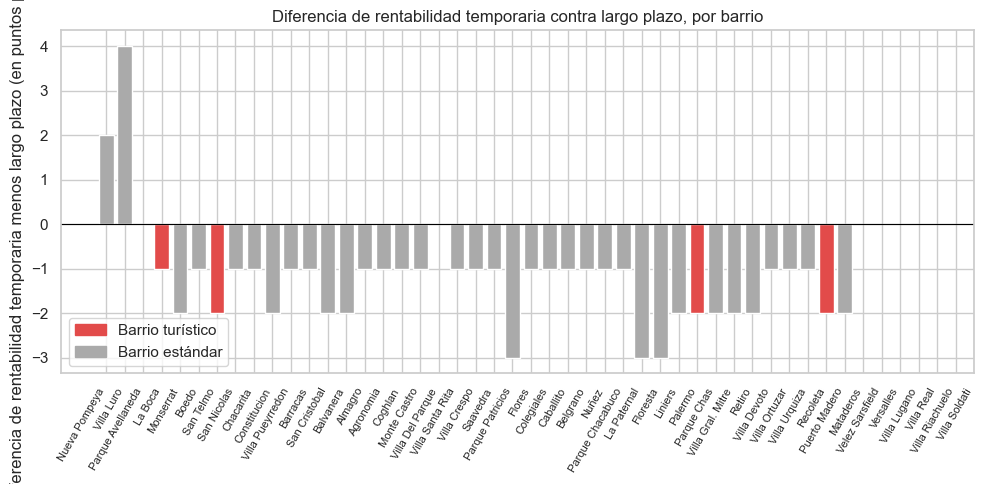

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
kpis_sorted = kpis.sort_values('rent_neta_temp_pct', ascending=False)
x = range(len(kpis_sorted))
colores = ['#E24B4A' if t else '#AAAAAA' for t in kpis_sorted['es_turistico']]
ax.bar(x, kpis_sorted['rent_neta_temp_pct'] - kpis_sorted['rent_neta_lp_pct'],
       color=colores, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(x))
ax.set_xticklabels(kpis_sorted.index, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Diferencia de rentabilidad temporaria menos largo plazo (en puntos porcentuales)')
ax.set_title('Diferencia de rentabilidad temporaria contra largo plazo, por barrio')
patch_t = mpatches.Patch(color='#E24B4A', label='Barrio turístico')
patch_n = mpatches.Patch(color='#AAAAAA', label='Barrio estándar')
ax.legend(handles=[patch_t, patch_n])
plt.tight_layout()
plt.show()

No llegamos a rechazar la hipótesis nula, así que no encontramos evidencia suficiente para afirmar que los barrios turísticos rinden más en alquiler temporario que en largo plazo. Una explicación posible es que con apenas cuatro barrios turísticos la muestra es muy chica para que un test como Mann-Whitney detecte la diferencia.

### Hipótesis 2. Mayor precio por metro cuadrado no implica mayor rentabilidad

In [24]:
# Hipótesis 2: los barrios con mayor precio por metro cuadrado no son los de mayor rentabilidad neta.
# La hipótesis nula sostiene que la correlación entre precio y rentabilidad es cero o positiva.
# La hipótesis alternativa sostiene que la correlación es negativa: los barrios caros rinden menos.

kpis = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis.copy()

# Usamos el precio mediano por metro cuadrado que ya viene calculado
h2 = kpis[['rent_neta_lp_pct', 'precio_m2_mediano']].dropna()

# Primer test: correlación de Spearman sobre todos los barrios
rho, p_rho = spearmanr(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'])
# Como la alternativa es direccional (negativa), el p-valor unilateral es la mitad del bilateral
p_unilateral = p_rho / 2 if rho < 0 else 1 - p_rho / 2

print('Hipótesis 2: precio por metro cuadrado contra rentabilidad neta a largo plazo')
print('La hipótesis nula es que la correlación es mayor o igual a cero')
print('Trabajamos con un nivel de significancia del 5 por ciento')
print(f'\nCorrelación de Spearman: {rho:.3f}')
print(f'p-valor bilateral: {p_rho:.4f}, p-valor unilateral: {p_unilateral:.4f}')
if p_unilateral < 0.05 and rho < 0:
    print('Rechazamos la hipótesis nula. Hay una correlación negativa significativa: los barrios más caros rinden menos. Hipótesis 2 confirmada.')
elif p_rho < 0.05 and rho > 0:
    print('Rechazamos la hipótesis nula en sentido contrario: la correlación es positiva. La hipótesis 2 no se confirma.')
else:
    print('No rechazamos la hipótesis nula. No hay evidencia de correlación negativa significativa.')

# Segundo test: comparación entre los 10 barrios más caros y el resto, como complemento narrativo
N_TOP = 10
top_barrios  = h2.nlargest(N_TOP, 'precio_m2_mediano')
resto        = h2[~h2.index.isin(top_barrios.index)]

stat_mw, p_mw = mannwhitneyu(
    top_barrios['rent_neta_lp_pct'].dropna(),
    resto['rent_neta_lp_pct'].dropna(),
    alternative='less'
)
print(f'\nMann-Whitney entre los {N_TOP} barrios más caros y el resto')
print('La hipótesis nula es que los más caros rinden igual o más que el resto')
print(f'Estadístico: {stat_mw:.2f}, p-valor: {p_mw:.4f}')
if p_mw < 0.05:
    print(f'Rechazamos la hipótesis nula. Los {N_TOP} barrios más caros tienen una rentabilidad neta significativamente menor.')
else:
    print(f'No rechazamos la hipótesis nula. No hay diferencia significativa entre los {N_TOP} más caros y el resto.')

Hipótesis 2: precio por metro cuadrado contra rentabilidad neta a largo plazo
La hipótesis nula es que la correlación es mayor o igual a cero
Trabajamos con un nivel de significancia del 5 por ciento

Correlación de Spearman: -0.806
p-valor bilateral: 0.0000, p-valor unilateral: 0.0000
Rechazamos la hipótesis nula. Hay una correlación negativa significativa: los barrios más caros rinden menos. Hipótesis 2 confirmada.

Mann-Whitney entre los 10 barrios más caros y el resto
La hipótesis nula es que los más caros rinden igual o más que el resto
Estadístico: 58.00, p-valor: 0.0002
Rechazamos la hipótesis nula. Los 10 barrios más caros tienen una rentabilidad neta significativamente menor.


Para confirmar si los barrios con mayor precio por metro cuadrado realmente no son los de mayor rentabilidad, hicimos dos pruebas. Primero un test de Spearman sobre todos los barrios, que nos dio una correlación negativa significativa entre precio por metro cuadrado y rentabilidad.

Después tomamos los diez barrios más caros y los comparamos contra el resto, para ver si rinden menos. También rechazamos la hipótesis nula, así que hay evidencia para decir que esos barrios más caros tienen una rentabilidad menor.

Esto sugiere que, para alguien que esté buscando alta rentabilidad sin tener preferencia particular por un barrio, probablemente no recomendemos los más caros.

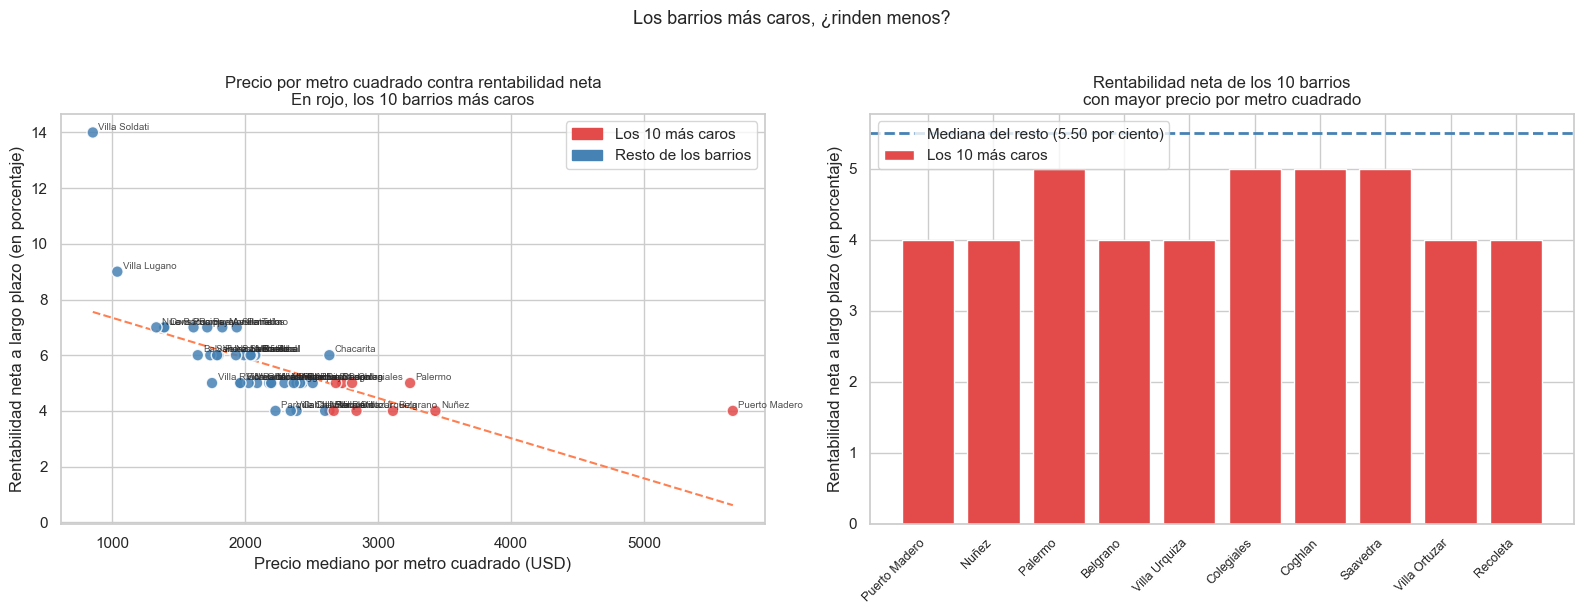

In [25]:
# Primer gráfico: dispersión con línea de tendencia para todos los barrios
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colores_scatter = ['#E24B4A' if b in top_barrios.index else 'steelblue' for b in h2.index]
ax.scatter(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'],
           color=colores_scatter, s=70, alpha=0.85, edgecolors='white', zorder=3)
for barrio, row in h2.iterrows():
    ax.annotate(barrio, (row['precio_m2_mediano'], row['rent_neta_lp_pct']),
                fontsize=7, alpha=0.8, xytext=(4, 2), textcoords='offset points')
xr = np.linspace(h2['precio_m2_mediano'].min(), h2['precio_m2_mediano'].max(), 100)
ax.plot(xr, np.poly1d(np.polyfit(h2['precio_m2_mediano'], h2['rent_neta_lp_pct'], 1))(xr),
        '--', color='coral', linewidth=1.5, label=f'Tendencia (correlación {rho:.2f})')
ax.set_xlabel('Precio mediano por metro cuadrado (USD)')
ax.set_ylabel('Rentabilidad neta a largo plazo (en porcentaje)')
ax.set_title('Precio por metro cuadrado contra rentabilidad neta\nEn rojo, los 10 barrios más caros')
patch_top  = mpatches.Patch(color='#E24B4A', label=f'Los {N_TOP} más caros')
patch_rest = mpatches.Patch(color='steelblue', label='Resto de los barrios')
ax.legend(handles=[patch_top, patch_rest])

# Segundo gráfico: barras de los 10 más caros contra la mediana del resto
ax2 = axes[1]
mediana_resto = resto['rent_neta_lp_pct'].median()
top_sorted = top_barrios.sort_values('precio_m2_mediano', ascending=False)

bars = ax2.bar(range(len(top_sorted)), top_sorted['rent_neta_lp_pct'],
               color='#E24B4A', edgecolor='white', label=f'Los {N_TOP} más caros')
ax2.axhline(mediana_resto, color='steelblue', linewidth=2, linestyle='--',
            label=f'Mediana del resto ({mediana_resto:.2f} por ciento)')
ax2.set_xticks(range(len(top_sorted)))
ax2.set_xticklabels(top_sorted.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Rentabilidad neta a largo plazo (en porcentaje)')
ax2.set_title(f'Rentabilidad neta de los {N_TOP} barrios\ncon mayor precio por metro cuadrado')
ax2.legend()

plt.suptitle('Los barrios más caros, ¿rinden menos?', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

El primer gráfico muestra la tendencia negativa entre el precio por metro cuadrado y la rentabilidad neta. El segundo deja clara la diferencia que tienen los diez barrios más caros frente al resto en términos de rentabilidad.

### Hipótesis 3. Los amenities aumentan el precio de venta pero no el de alquiler

Comparamos con Mann-Whitney el precio por metro cuadrado entre propiedades con y sin cada amenity, para cada tipo de operación.

In [26]:
df.columns

Index(['posting_id', 'sitio', 'operacion', 'precio', 'calle', 'altura',
       'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
       'luminoso', 'balcon_aterrazado', 'barrio_oficial', 'moneda',
       'accesible_movilidad_reducida', 'acepta_caucion',
       'agua_caliente_central', 'ambientes', 'antiguedad_años',
       'apto_profesional', 'ascensor', 'balcon', 'baulera', 'baños',
       'dependencia_servicio', 'dormitorios', 'expensas_incluidas_en_precio',
       'gimnasio', 'lavadero', 'm2_total', 'ofrece_financiacion', 'parrilla',
       'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'expensas',
       'sobre_avenida', 'precio_por_m2', 'segmento_zona',
       'segmento_zona_modelo', 'log_precio', 'log_m2', 'log_precio_m2',
       'amenities_count', 'm2_relativo_barrio', 'lat', 'lon', 'geo_source',
       'precio_usd', 'precio_por_m2_usd', 'dist_subte_km', 'lat_barrio',
       'lon_barrio', 'dist_verde_km', 'dist_tren_km', 'nivel_socioeconomico'],
   

In [27]:
AMENITIES_H3 = ['pileta', 'gimnasio', 'balcon', 'baulera', 'parrilla', 'sum']
amenities_presentes = [a for a in AMENITIES_H3 if a in df.columns]

resultados_h3 = []
for amenity in amenities_presentes:
    for operacion in ['venta', 'alquiler', 'alquiler_temporal']:
        subset = df[(df['operacion'] == operacion) & df['precio_por_m2_usd'].notna()]
        con    = subset[subset[amenity] == 1]['precio_por_m2_usd']
        sin_am = subset[subset[amenity] == 0]['precio_por_m2_usd']
        if len(con) < 10 or len(sin_am) < 10:
            continue
        stat, p = mannwhitneyu(con, sin_am, alternative='greater')
        resultados_h3.append({
            'amenity': amenity,
            'operacion': operacion,
            'mediana_con': con.median(),
            'mediana_sin': sin_am.median(),
            'dif_%': (con.median() - sin_am.median()) / sin_am.median() * 100,
            'p_valor': p,
            'significativo': 'Sí' if p < 0.05 else 'No'
        })

df_h3 = pd.DataFrame(resultados_h3)
print('Hipótesis 3: impacto de los amenities sobre el precio por metro cuadrado, según el tipo de operación')
print(df_h3.to_string(index=False))

print('\nConclusión por amenity')
for amenity in amenities_presentes:
    fila_venta    = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'venta')]
    fila_alq      = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler')]
    fila_alq_temp = df_h3[(df_h3['amenity'] == amenity) & (df_h3['operacion'] == 'alquiler_temporal')]

    sig_venta    = (not fila_venta.empty)    and fila_venta['significativo'].values[0]    == 'Sí'
    sig_alq      = (not fila_alq.empty)      and fila_alq['significativo'].values[0]      == 'Sí'
    sig_alq_temp = (not fila_alq_temp.empty) and fila_alq_temp['significativo'].values[0] == 'Sí'

    # Venta contra alquiler tradicional
    if fila_venta.empty or fila_alq.empty:
        concl_lp = 'Sin datos suficientes'
    elif sig_venta and not sig_alq:
        concl_lp = 'Hipótesis confirmada: aumenta en venta pero no en alquiler tradicional'
    elif sig_venta and sig_alq:
        concl_lp = 'Aumenta en venta y también en alquiler tradicional'
    else:
        concl_lp = 'Hipótesis no confirmada: no aumenta significativamente en venta'

    # Venta contra alquiler temporario
    if fila_venta.empty or fila_alq_temp.empty:
        concl_temp = 'Sin datos suficientes'
    elif sig_venta and not sig_alq_temp:
        concl_temp = 'Hipótesis confirmada: aumenta en venta pero no en alquiler temporario'
    elif sig_venta and sig_alq_temp:
        concl_temp = 'Aumenta en venta y también en alquiler temporario'
    else:
        concl_temp = 'Hipótesis no confirmada: no aumenta significativamente en venta'

    print(f'\n{amenity}')
    print(f'  contra alquiler tradicional: {concl_lp}')
    print(f'  contra alquiler temporario:  {concl_temp}')

Hipótesis 3: impacto de los amenities sobre el precio por metro cuadrado, según el tipo de operación
 amenity         operacion  mediana_con  mediana_sin  dif_%  p_valor significativo
  pileta             venta    3,365.116    2,342.600 43.649    0.000            Sí
  pileta          alquiler       17.163       12.367 38.776    0.000            Sí
  pileta alquiler_temporal       21.094       15.682 34.511    0.000            Sí
gimnasio             venta    3,661.972    2,416.473 51.542    0.000            Sí
gimnasio          alquiler       20.000       12.519 59.758    0.000            Sí
gimnasio alquiler_temporal       23.077       16.129 43.077    0.000            Sí
  balcon             venta    2,684.211    2,266.667 18.421    0.000            Sí
  balcon          alquiler       13.349       12.620  5.778    0.000            Sí
  balcon alquiler_temporal       17.668       16.406  7.692    0.000            Sí
 baulera             venta    2,831.592    2,500.000 13.264    0.000 

### Hipótesis 4. La cercanía al subte impacta en el precio por metro cuadrado

In [28]:
# Hipótesis 4: distancia al subte contra precio por metro cuadrado, a nivel propiedad.
# Cada propiedad tiene su propia coordenada y su propia distancia al subte,
# así que el test trabaja con esa granularidad real y no con medianas por barrio.

subset_h4 = df[
    (df['operacion'] == 'venta') &
    df['precio_por_m2_usd'].notna() &
    df['dist_subte_km'].notna()
].copy()

rho_h4, p_h4 = spearmanr(subset_h4['dist_subte_km'], subset_h4['precio_por_m2_usd'])

print('Hipótesis 4: distancia al subte contra precio por metro cuadrado, en ventas en dólares, a nivel propiedad')
print(f'Cantidad de propiedades analizadas: {len(subset_h4):,}')
print(f'Correlación de Spearman: {rho_h4:.3f}, p-valor: {p_h4:.4g}')
if p_h4 < 0.05:
    if rho_h4 < 0:
        print('Rechazamos la hipótesis nula. A mayor distancia al subte, menor precio por metro cuadrado. Hipótesis 4 confirmada.')
    else:
        print('Rechazamos la hipótesis nula, pero con signo contrario al esperado: la correlación es positiva.')
else:
    print('No rechazamos la hipótesis nula. No hay correlación significativa con la distancia al subte.')

# Agrupamos por rangos de distancia para ver la relación de manera más intuitiva
bins = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 100]
labels = ['menos de 250 m', '250 a 500 m', '500 a 750 m', '750 m a 1 km',
          '1 a 1.5 km', '1.5 a 2 km', '2 a 3 km', 'más de 3 km']
subset_h4['bucket_subte'] = pd.cut(subset_h4['dist_subte_km'], bins=bins, labels=labels)
bucket_stats = (subset_h4.groupby('bucket_subte', observed=True)
                         .agg(n=('precio_por_m2_usd', 'size'),
                              precio_m2_mediano=('precio_por_m2_usd', 'median'),
                              precio_m2_p25=('precio_por_m2_usd', lambda s: s.quantile(0.25)),
                              precio_m2_p75=('precio_por_m2_usd', lambda s: s.quantile(0.75))))
print('\nPrecio por metro cuadrado en dólares según la distancia al subte, a nivel propiedad:')
print(bucket_stats.round(0).to_string())

Hipótesis 4: distancia al subte contra precio por metro cuadrado, en ventas en dólares, a nivel propiedad
Cantidad de propiedades analizadas: 24,974
Correlación de Spearman: 0.137, p-valor: 5.883e-105
Rechazamos la hipótesis nula, pero con signo contrario al esperado: la correlación es positiva.

Precio por metro cuadrado en dólares según la distancia al subte, a nivel propiedad:
                   n  precio_m2_mediano  precio_m2_p25  precio_m2_p75
bucket_subte                                                         
menos de 250 m  4343          2,222.000      1,753.000      2,811.000
250 a 500 m     7114          2,479.000      1,964.000      3,118.000
500 a 750 m     4453          2,788.000      2,234.000      3,483.000
750 m a 1 km    2747          3,000.000      2,464.000      3,659.000
1 a 1.5 km      2267          2,778.000      2,183.000      3,679.000
1.5 a 2 km      1068          2,510.000      1,969.000      3,592.000
2 a 3 km        1345          2,262.000      1,815.000   

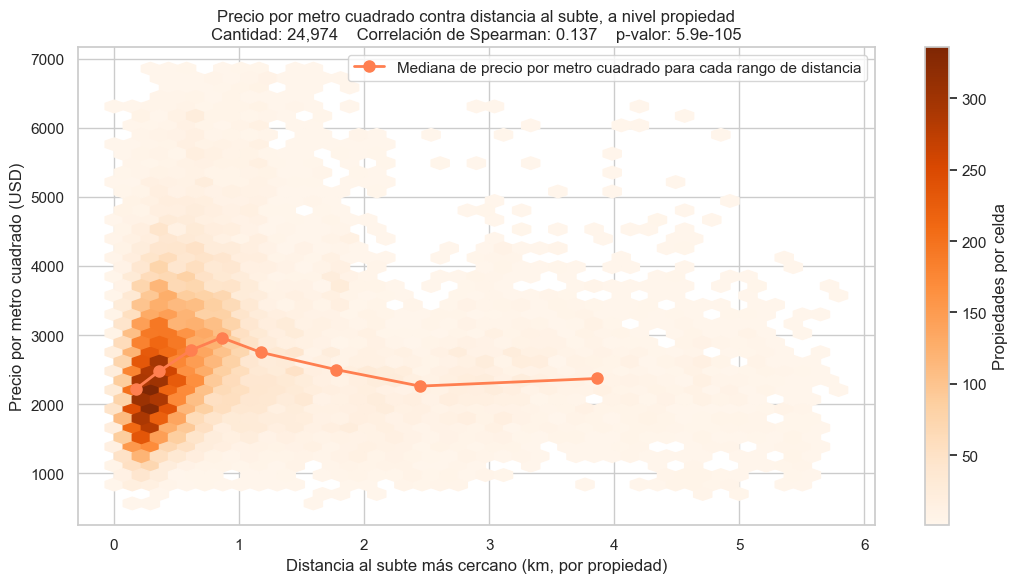

In [29]:
# Visualización a nivel propiedad. Mostramos la densidad con un hexbin
# y encima la mediana por bucket de distancia. Recortamos el uno por ciento
# superior de precios para que la escala se lea bien.
top = subset_h4['precio_por_m2_usd'].quantile(0.99)
plot_data = subset_h4[subset_h4['precio_por_m2_usd'] <= top]

# Para la línea, usamos el centro real de cada bucket (mediana de las distancias
# dentro de ese bucket), no el punto medio geométrico
bucket_med = (plot_data.groupby('bucket_subte', observed=True)
                       .agg(centro_km=('dist_subte_km', 'median'),
                            precio_med=('precio_por_m2_usd', 'median'))
                       .reset_index()
                       .sort_values('centro_km'))

fig, ax = plt.subplots(figsize=(11, 6))
hb = ax.hexbin(plot_data['dist_subte_km'], plot_data['precio_por_m2_usd'],
               gridsize=40, cmap='Oranges', mincnt=1)
fig.colorbar(hb, ax=ax, label='Propiedades por celda')
ax.plot(bucket_med['centro_km'], bucket_med['precio_med'], 'o-',
        color='coral', linewidth=2, markersize=8,
        label='Mediana de precio por metro cuadrado para cada rango de distancia')
ax.set_xlabel('Distancia al subte más cercano (km, por propiedad)')
ax.set_ylabel('Precio por metro cuadrado (USD)')
ax.set_title(f'Precio por metro cuadrado contra distancia al subte, a nivel propiedad\n'
             f'Cantidad: {len(subset_h4):,}    Correlación de Spearman: {rho_h4:.3f}    p-valor: {p_h4:.2g}')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# 4. Reducción de dimensionalidad e índices sintéticos

En la entrega anterior generamos muchas variables binarias de amenities, lo que viene bien para el feature engineering pero complica los modelos. Usar todas esas variables juntas mete multicolinealidad y hace más difícil interpretar los resultados.

Para resolverlo aplicamos dos técnicas complementarias. PCA sobre las variables continuas que describen la propiedad, que nos permite resumir precio, superficie y antigüedad en dos componentes con interpretación clara. Y MCA sobre los amenities binarios, que nos da un Índice de Lujo unificado. Sumamos además un Índice de Confort y un Score de Antigüedad explícitos, para que después los modelos puedan separar bien estos efectos.

### 4.1 PCA sobre las variables continuas de la propiedad

In [30]:
VARS_PCA = ['precio_por_m2_usd', 'm2_total', 'antiguedad_años']
vars_pca_ok = [v for v in VARS_PCA if v in df.columns]

df_pca_base = df[vars_pca_ok].dropna()

print(f'Registros válidos para el PCA: {len(df_pca_base):,}')
print(f'Variables usadas: {vars_pca_ok}')

Registros válidos para el PCA: 51,992
Variables usadas: ['precio_por_m2_usd', 'm2_total', 'antiguedad_años']


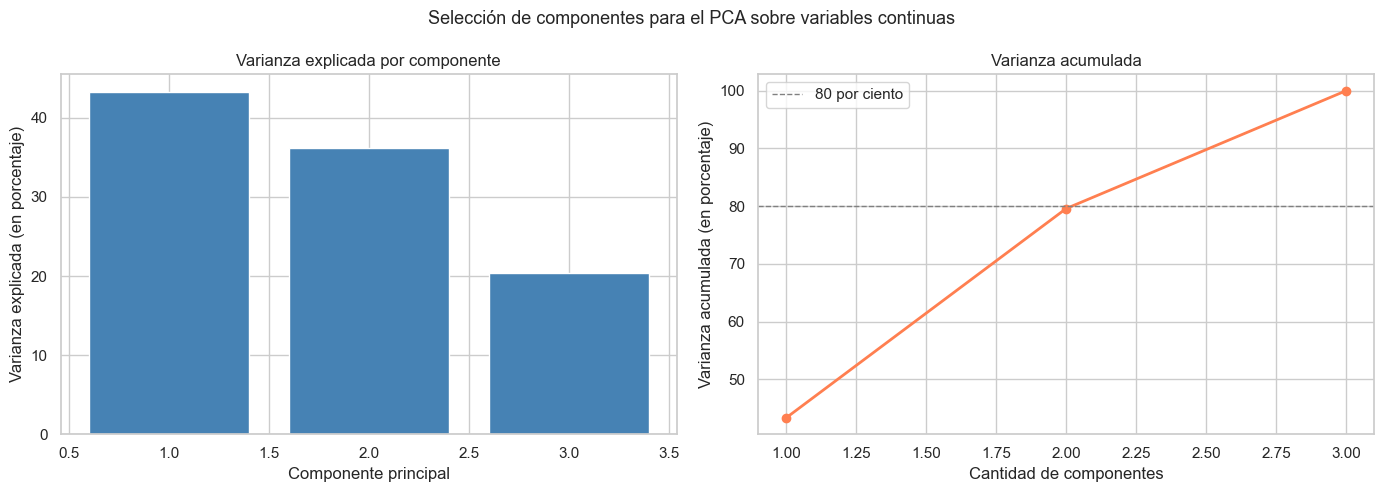

Varianza explicada por componente:
  Componente 1: 43.3 por ciento (acumulado: 43.3 por ciento)
  Componente 2: 36.2 por ciento (acumulado: 79.6 por ciento)
  Componente 3: 20.4 por ciento (acumulado: 100.0 por ciento)


In [31]:
# Escalamos las variables porque el PCA es sensible a la escala
scaler_pca = StandardScaler()
X_pca = scaler_pca.fit_transform(df_pca_base)

# Ajustamos el PCA con todos los componentes para poder ver el gráfico de codo
pca_full = PCA(n_components=len(vars_pca_ok), random_state=SEED)
pca_full.fit(X_pca)

varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada por cada componente
axes[0].bar(range(1, len(vars_pca_ok)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (en porcentaje)')
axes[0].set_title('Varianza explicada por componente')

# Varianza acumulada
axes[1].plot(range(1, len(vars_pca_ok)+1), varianza_acumulada * 100,
             marker='o', color='coral', linewidth=2)
axes[1].axhline(80, linestyle='--', color='gray', linewidth=1, label='80 por ciento')
axes[1].set_xlabel('Cantidad de componentes')
axes[1].set_ylabel('Varianza acumulada (en porcentaje)')
axes[1].set_title('Varianza acumulada')
axes[1].legend()

plt.suptitle('Selección de componentes para el PCA sobre variables continuas', fontsize=13)
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:')
for i, v in enumerate(pca_full.explained_variance_ratio_):
    print(f'  Componente {i+1}: {v*100:.1f} por ciento (acumulado: {varianza_acumulada[i]*100:.1f} por ciento)')

Elegimos quedarnos con dos componentes porque entre los dos explican alrededor del 80 por ciento de la varianza, y agregar un tercero solo aportaría un porcentaje residual a costa de complejidad. Es un buen equilibrio entre parsimonia y representatividad. La consigna pide interpretar bien los componentes principales, y en este caso los dos que conservamos tienen una lectura comercial bastante directa.

Loadings del PCA, es decir cómo se correlaciona cada variable con cada componente:
                    PC1    PC2
precio_por_m2_usd 0.523 -0.648
m2_total          0.750  0.041
antiguedad_años   0.405  0.760


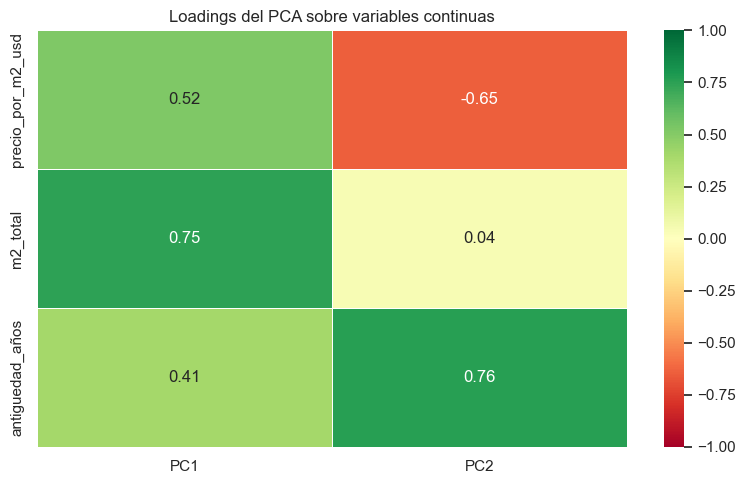

In [32]:
# Elegimos quedarnos con dos componentes, que juntos explican cerca del 80 por ciento de la varianza
N_PCA = 2
pca_2 = PCA(n_components=N_PCA, random_state=SEED)
coords_pca = pca_2.fit_transform(X_pca)

# Interpretamos los loadings para entender qué representa cada componente
loadings = pd.DataFrame(
    pca_2.components_.T,
    index=vars_pca_ok,
    columns=[f'PC{i+1}' for i in range(N_PCA)]
)
print('Loadings del PCA, es decir cómo se correlaciona cada variable con cada componente:')
print(loadings.round(3))

# Heatmap para visualizar los loadings
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Loadings del PCA sobre variables continuas')
plt.tight_layout()
plt.show()

### Interpretación de los componentes

El primer componente se mueve fuerte con el precio por metro cuadrado y con la superficie total. Esto tiene sentido: ambas variables suelen subir juntas dentro de un segmento de mercado. Lo podemos pensar como un índice general de valor y tamaño. Cuando un departamento puntúa alto en este componente, es porque combina superficie grande con precio por metro cuadrado alto, dos atributos típicos de propiedades de gama media alta o premium.

El segundo componente está dominado por la antigüedad, con el precio por metro cuadrado entrando con signo contrario. Cuando la antigüedad sube, el precio por metro cuadrado tiende a bajar dentro de un mismo rango de superficie. A este componente lo vamos a tratar como índice de antigüedad. Una propiedad con score alto acá es vieja y relativamente más barata por metro cuadrado.

In [33]:
idx_pca = df_pca_base.index
df.loc[idx_pca, 'pca_precio_sup']  = coords_pca[:, 0]
df.loc[idx_pca, 'pca_antiguedad']  = coords_pca[:, 1]

print(f'Asignamos los scores del PCA a {len(idx_pca):,} registros')
print('\nEstadísticas del primer componente, el índice de precio y superficie:')
print(df['pca_precio_sup'].dropna().describe())
print('\nEstadísticas del segundo componente, el índice de antigüedad:')
print(df['pca_antiguedad'].dropna().describe())

Asignamos los scores del PCA a 51,992 registros

Estadísticas del primer componente, el índice de precio y superficie:
count   51,992.000
mean         0.000
std          1.140
min         -1.711
25%         -0.769
50%         -0.187
75%          0.484
max         11.897
Name: pca_precio_sup, dtype: float64

Estadísticas del segundo componente, el índice de antigüedad:
count   51,992.000
mean        -0.000
std          1.043
min         -6.386
25%         -0.670
50%          0.069
75%          0.739
max          4.578
Name: pca_antiguedad, dtype: float64


### 4.2 Score de Antigüedad como variable explícita

A partir del segundo componente del PCA construimos un Score de Antigüedad nombrado, que después usamos en el clustering y en los modelos. Lo llevamos al rango cero a uno para que sea más fácil de leer, donde un valor cercano a uno representa propiedades viejas y relativamente baratas por metro cuadrado, y un valor cercano a cero representa propiedades nuevas o caras dentro del segmento.

Tener este score como una columna aparte sirve por dos motivos. Primero, es más interpretable que decir "el segundo componente del PCA". Segundo, los modelos explicativos que vienen después pueden tratarlo como una feature continua estandar y devolver un coeficiente con lectura directa.

In [34]:
from sklearn.preprocessing import MinMaxScaler

# Normalizamos el segundo componente al rango 0-1 para que sea más interpretable
mask_pca = df['pca_antiguedad'].notna()
scaler_age = MinMaxScaler()
score = scaler_age.fit_transform(df.loc[mask_pca, ['pca_antiguedad']]).flatten()
df.loc[mask_pca, 'score_antiguedad'] = score

print('Estadísticas del Score de Antigüedad (0 propiedad nueva o cara, 1 propiedad vieja o barata):')
print(df['score_antiguedad'].dropna().describe())

# Sanity check: el score tiene que correlacionar con la antigüedad cruda
from scipy.stats import spearmanr
sub = df[['score_antiguedad', 'antiguedad_años']].dropna()
rho, _ = spearmanr(sub['score_antiguedad'], sub['antiguedad_años'])
print(f'\nCorrelación con la antigüedad en años: {rho:.3f}')

Estadísticas del Score de Antigüedad (0 propiedad nueva o cara, 1 propiedad vieja o barata):
count   51,992.000
mean         0.582
std          0.095
min          0.000
25%          0.521
50%          0.589
75%          0.650
max          1.000
Name: score_antiguedad, dtype: float64

Correlación con la antigüedad en años: 0.809


### 4.3 MCA sobre los amenities binarios

Aplicamos MCA, que es el equivalente del PCA para variables categóricas, sobre el conjunto de amenities binarios. La idea es resumir muchas variables 0/1 en un único índice continuo que represente la presencia de amenities en general.

En una primera versión incluíamos también variables de conteo como la cantidad de ambientes, baños o dormitorios. Eso sesgaba el primer componente hacia el tamaño de la propiedad y no hacia el nivel de equipamiento, que era lo que queríamos capturar. Acá lo separamos: solo entran al MCA los amenities binarios. Las variables de conteo se mantienen como features continuas para los modelos posteriores.

In [35]:
# Solo amenities binarios. Sacamos las variables de conteo y las categóricas de zona.
AMENITIES_BIN = [
    'losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad',
    'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida',
    'acepta_caucion', 'agua_caliente_central', 'apto_profesional', 'ascensor',
    'balcon', 'baulera', 'dependencia_servicio', 'expensas_incluidas_en_precio',
    'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla', 'pileta',
    'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida'
]
amenities_bin_ok = [a for a in AMENITIES_BIN if a in df.columns]

# El MCA necesita variables categóricas, así que pasamos todo a string
df_mca_base = df[amenities_bin_ok].fillna(0).astype(str)

print(f'Cantidad de amenities binarios que entran al MCA: {len(amenities_bin_ok)}')
print(amenities_bin_ok)

mca = prince.MCA(n_components=2, n_iter=10, random_state=SEED)
mca = mca.fit(df_mca_base)

try:
    eig = mca.eigenvalues_summary
    print('\nVarianza explicada por cada componente del MCA:')
    print(eig)
except Exception:
    print('\nEsta versión de prince no devuelve los eigenvalues directamente.')

# Coordenadas de las filas, que son los scores de cada propiedad
coords_mca = mca.row_coordinates(df_mca_base)

# El primer componente captura la presencia general de amenities,
# así que lo tomamos como Índice de Lujo refinado
df['indice_lujo'] = coords_mca.iloc[:, 0].values

print('\nEstadísticas del Índice de Lujo:')
print(df['indice_lujo'].describe())

Cantidad de amenities binarios que entran al MCA: 26
['losa_central', 'aire_acond', 'apto_credito', 'cochera', 'seguridad', 'luminoso', 'balcon_aterrazado', 'accesible_movilidad_reducida', 'acepta_caucion', 'agua_caliente_central', 'apto_profesional', 'ascensor', 'balcon', 'baulera', 'dependencia_servicio', 'expensas_incluidas_en_precio', 'gimnasio', 'lavadero', 'ofrece_financiacion', 'parrilla', 'pileta', 'portero', 'sum', 'terraza', 'tiene_expensas', 'sobre_avenida']

Varianza explicada por cada componente del MCA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.134        13.43%                     13.43%
1              0.066         6.61%                     20.05%

Estadísticas del Índice de Lujo:
count   51,992.000
mean        -0.000
std          0.367
min         -0.526
25%         -0.296
50%         -0.117
75%          0.236
max          1.452
Name: indice_lujo, dtype: float64


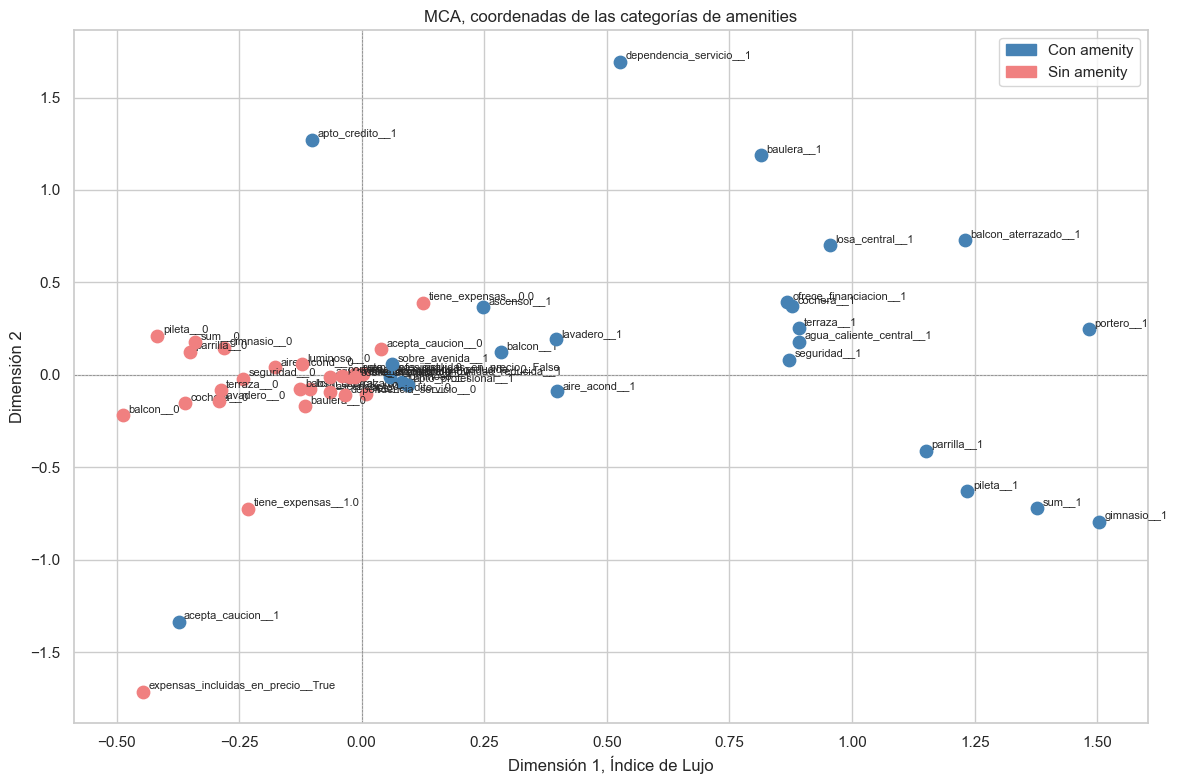

In [36]:
# Visualizamos las coordenadas de las categorías de los amenities
try:
    col_coords = mca.column_coordinates(df_mca_base)
    col_coords.columns = ['Dim0', 'Dim1']
    col_coords['variable'] = [c.rsplit('_', 1)[0] for c in col_coords.index]
    col_coords['valor'] = [c.rsplit('_', 1)[1] if '_' in c else c for c in col_coords.index]

    fig, ax = plt.subplots(figsize=(12, 8))
    for _, row in col_coords.iterrows():
        color = 'steelblue' if row['valor'] == '1' else 'lightcoral'
        ax.scatter(row['Dim0'], row['Dim1'], color=color, s=80, zorder=3)
        ax.annotate(row.name, (row['Dim0'], row['Dim1']),
                    fontsize=8, xytext=(4, 2), textcoords='offset points')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel('Dimensión 1, Índice de Lujo')
    ax.set_ylabel('Dimensión 2')
    ax.set_title('MCA, coordenadas de las categorías de amenities')
    p1 = mpatches.Patch(color='steelblue', label='Con amenity')
    p0 = mpatches.Patch(color='lightcoral', label='Sin amenity')
    ax.legend(handles=[p1, p0])
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'No pudimos hacer la visualización de coordenadas: {e}')

### 4.4 Índice de Confort como variable separada del Lujo

El Índice de Lujo captura amenities de gama alta como pileta, gimnasio o SUM, que apuntan a propiedades premium. Por separado armamos un Índice de Confort que captura amenities de comodidad cotidiana: aire acondicionado, ascensor, agua caliente central, lavadero, portero, losa central. Son cosas que una propiedad puede tener sin ser de lujo, pero que mejoran la calidad de vida en el día a día.

Lo construimos como la proporción de amenities de confort presentes en cada propiedad, en una escala de cero a uno. Un valor cercano a uno significa que la propiedad tiene casi todos los amenities de comodidad básica. La idea es que el cliente principiante pueda diferenciar una propiedad práctica para vivir de una propiedad pensada como inversión de lujo.

In [37]:
AMENITIES_CONFORT = [
    'aire_acond', 'ascensor', 'agua_caliente_central',
    'lavadero', 'portero', 'losa_central'
]
amenities_confort_ok = [a for a in AMENITIES_CONFORT if a in df.columns]

df['indice_confort'] = (
    df[amenities_confort_ok].fillna(0).sum(axis=1) / len(amenities_confort_ok)
)

print(f'Amenities incluidos en el Índice de Confort: {amenities_confort_ok}')
print(f'\nDistribución del Índice de Confort (0 ningún amenity, 1 todos):')
print(df['indice_confort'].describe())

# Vemos cuánto se solapa con el Índice de Lujo
rho_lc, _ = spearmanr(df['indice_lujo'].dropna(),
                       df.loc[df['indice_lujo'].notna(), 'indice_confort'])
print(f'\nCorrelación de Spearman entre Lujo y Confort: {rho_lc:.3f}')
print('Si fuera muy cercana a 1, estaríamos midiendo lo mismo. Una correlación')
print('moderada confirma que los dos índices capturan dimensiones distintas.')

Amenities incluidos en el Índice de Confort: ['aire_acond', 'ascensor', 'agua_caliente_central', 'lavadero', 'portero', 'losa_central']

Distribución del Índice de Confort (0 ningún amenity, 1 todos):
count   51,992.000
mean         0.189
std          0.174
min          0.000
25%          0.000
50%          0.167
75%          0.333
max          1.000
Name: indice_confort, dtype: float64

Correlación de Spearman entre Lujo y Confort: 0.519
Si fuera muy cercana a 1, estaríamos midiendo lo mismo. Una correlación
moderada confirma que los dos índices capturan dimensiones distintas.


### 4.5 Validación de los índices contra el precio

Probamos si los tres índices que construimos tienen sentido económico, viendo cómo se correlacionan con el precio por metro cuadrado en las ventas. Si los índices capturan algo real del valor de la propiedad, deberíamos ver correlaciones positivas y significativas para Lujo y Confort, y negativa o nula para el Score de Antigüedad (porque ese score sube cuando la propiedad es más vieja y barata).

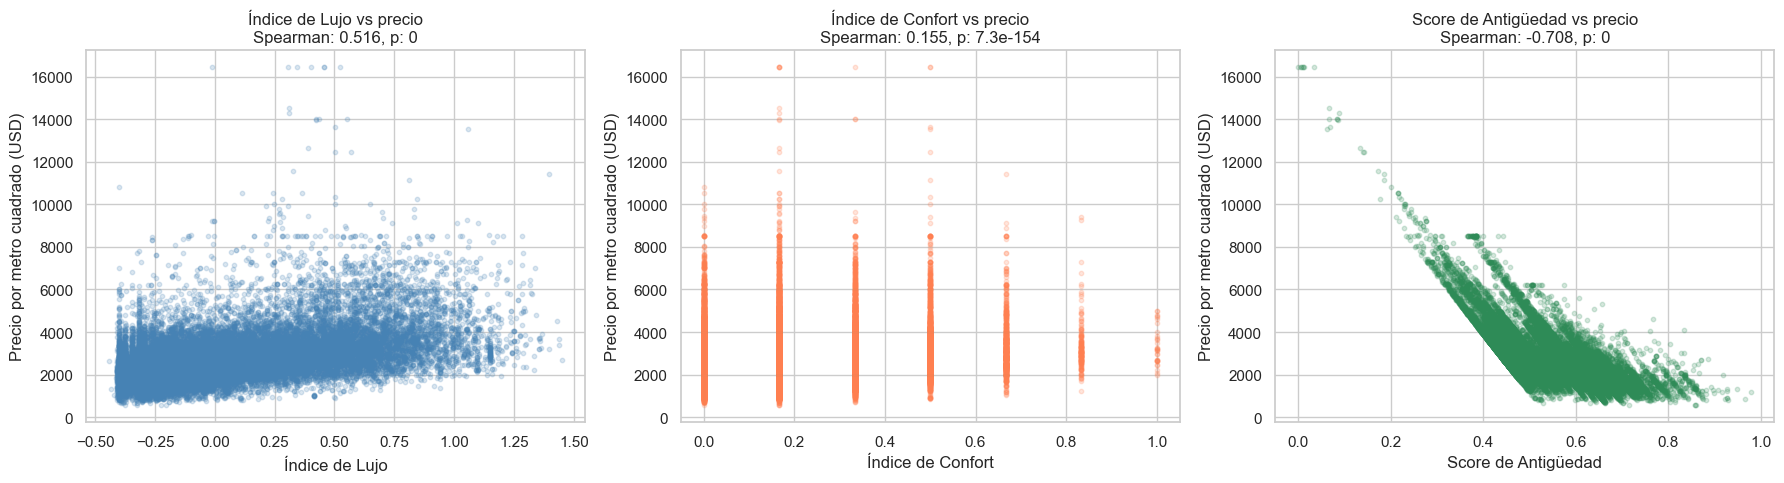

Índice de Lujo vs precio por metro cuadrado: Spearman 0.516, p-valor 0
Índice de Confort vs precio por metro cuadrado: Spearman 0.155, p-valor 7.296e-154
Score de Antigüedad vs precio por metro cuadrado: Spearman -0.708, p-valor 0


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

subset_val = df[
    (df['operacion'] == 'venta') & (df['moneda'] == 'usd') &
    df['precio_por_m2'].notna()
].copy()

# Índice de Lujo
axes[0].scatter(
    subset_val['indice_lujo'], subset_val['precio_por_m2'],
    alpha=0.2, s=10, color='steelblue'
)
rho_l, p_l = spearmanr(subset_val['indice_lujo'], subset_val['precio_por_m2'])
axes[0].set_xlabel('Índice de Lujo')
axes[0].set_ylabel('Precio por metro cuadrado (USD)')
axes[0].set_title(f'Índice de Lujo vs precio\nSpearman: {rho_l:.3f}, p: {p_l:.2g}')

# Índice de Confort
axes[1].scatter(
    subset_val['indice_confort'], subset_val['precio_por_m2'],
    alpha=0.2, s=10, color='coral'
)
rho_c, p_c = spearmanr(subset_val['indice_confort'], subset_val['precio_por_m2'])
axes[1].set_xlabel('Índice de Confort')
axes[1].set_ylabel('Precio por metro cuadrado (USD)')
axes[1].set_title(f'Índice de Confort vs precio\nSpearman: {rho_c:.3f}, p: {p_c:.2g}')

# Score de Antigüedad
sub_age = subset_val[subset_val['score_antiguedad'].notna()]
axes[2].scatter(
    sub_age['score_antiguedad'], sub_age['precio_por_m2'],
    alpha=0.2, s=10, color='seagreen'
)
rho_a, p_a = spearmanr(sub_age['score_antiguedad'], sub_age['precio_por_m2'])
axes[2].set_xlabel('Score de Antigüedad')
axes[2].set_ylabel('Precio por metro cuadrado (USD)')
axes[2].set_title(f'Score de Antigüedad vs precio\nSpearman: {rho_a:.3f}, p: {p_a:.2g}')

plt.tight_layout()
plt.show()

print(f'Índice de Lujo vs precio por metro cuadrado: Spearman {rho_l:.3f}, p-valor {p_l:.4g}')
print(f'Índice de Confort vs precio por metro cuadrado: Spearman {rho_c:.3f}, p-valor {p_c:.4g}')
print(f'Score de Antigüedad vs precio por metro cuadrado: Spearman {rho_a:.3f}, p-valor {p_a:.4g}')

# 5. Clustering para descubrir micro-mercados

Buscamos grupos de propiedades que compartan características similares sin importar en qué barrio están, para detectar micro-mercados que no se ven mirando los barrios uno por uno. La consigna del trabajo lo pide en estos términos: aplicar un algoritmo no supervisado, bautizar los grupos resultantes con una lectura comercial, y usar esa nueva clasificación como variable clave en el análisis.

### 5.1 Selección de variables para el clustering

Usamos un conjunto amplio de features que cubren tres dimensiones: características de la propiedad (precio por metro cuadrado, superficie, antigüedad), nivel de equipamiento (Índice de Lujo y de Confort) y entorno espacial (distancias al subte, espacios verdes y tren, además del nivel socioeconómico del barrio).

In [39]:
VARS_CLUSTER = [
    'precio_por_m2_usd', 'm2_total', 'antiguedad_años',
    'indice_lujo', 'indice_confort',
    'dist_subte_km', 'dist_verde_km', 'dist_microcentro_km', 'dist_tren_km',
    'nivel_socioeconomico'
]

vars_cluster_ok = [v for v in VARS_CLUSTER if v in df.columns]

# Usamos ventas en dólares para el clustering principal
df_clust_base = df[vars_cluster_ok + ['barrio_oficial', 'precio_por_m2', 'operacion']].dropna()

print(f'Registros para clustering: {len(df_clust_base):,}')
print(f'Variables usadas ({len(vars_cluster_ok)}):')
for v in vars_cluster_ok:
    print(f'  - {v}')

Registros para clustering: 0
Variables usadas (9):
  - precio_por_m2_usd
  - m2_total
  - antiguedad_años
  - indice_lujo
  - indice_confort
  - dist_subte_km
  - dist_verde_km
  - dist_tren_km
  - nivel_socioeconomico


### 5.2 Selección del número de clusters

In [40]:
from sklearn.metrics import calinski_harabasz_score

scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_clust_base[vars_cluster_ok])

K_RANGE = range(2, 11)
inercias = []
siluetas = []
vrc = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    labels = km.fit_predict(X_clust)
    inercias.append(km.inertia_)
    sil = silhouette_score(X_clust, labels, sample_size=5000, random_state=SEED)
    siluetas.append(sil)
    vrc_val = calinski_harabasz_score(X_clust, labels)
    vrc.append(vrc_val)
    print(f'k = {k}: inercia = {km.inertia_:,.0f}, silueta = {sil:.3f}, índice Calinski-Harabasz = {vrc_val:.3f}')

ValueError: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by StandardScaler.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(list(K_RANGE), inercias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Cantidad de clusters')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo para elegir la cantidad de clusters')
axes[0].set_xticks(list(K_RANGE))

# Silueta
axes[1].plot(list(K_RANGE), siluetas, marker='o', color='coral', linewidth=2)
axes[1].set_xlabel('Cantidad de clusters')
axes[1].set_ylabel('Score de silueta')
axes[1].set_title('Score de silueta. Cuanto más alto, mejor está la separación')
axes[1].set_xticks(list(K_RANGE))

plt.suptitle('Selección de la cantidad óptima de clusters', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
plt.plot(K_RANGE, vrc, marker='o')
plt.xlabel('Cantidad de clusters')
plt.ylabel('Índice de Calinski-Harabasz')
plt.title('Índice de Calinski-Harabasz según la cantidad de clusters')
plt.grid(True)
plt.show()

### 5.3 Decisión y asignación final

Después de mirar las tres métricas, elegimos cuatro clusters. El gráfico del codo muestra un quiebre suave en ese valor. La silueta favorece valores muy bajos (k = 2) pero esa segmentación es demasiado gruesa para usar como base comercial. El índice de Calinski-Harabasz acompaña bien a k = 4 como punto de equilibrio.

Cuatro grupos también es un número manejable para presentarle al inversor: pocos como para que cada uno tenga identidad, suficientes como para diferenciar perfiles relevantes.

In [ ]:
K_FINAL = 4
print(f'Cantidad final de clusters: {K_FINAL}')

km_final = KMeans(n_clusters=K_FINAL, random_state=SEED, n_init='auto')
df_clust_base['cluster'] = km_final.fit_predict(X_clust)

# Mapeamos el cluster al dataframe principal
df.loc[df_clust_base.index, 'cluster'] = df_clust_base['cluster'].astype(int)

print('Distribución por cluster:')
print(df_clust_base['cluster'].value_counts().sort_index())

### 5.4 Perfil de cada cluster

In [ ]:
perfil_mediana = df_clust_base.groupby('cluster')[vars_cluster_ok].median().round(2)
perfil_mediana['n_propiedades'] = df_clust_base.groupby('cluster').size()
print('Perfil de cada cluster, con la mediana de cada variable:')
print(perfil_mediana.to_string())

In [ ]:
# Barrios dominantes en cada cluster
barrio_cluster = (
    df_clust_base.groupby(['cluster', 'barrio_oficial'])
    .size()
    .reset_index(name='n')
    .sort_values(['cluster', 'n'], ascending=[True, False])
    .groupby('cluster')
    .head(5)
)
print('Los cinco barrios más representados en cada cluster:')
print(barrio_cluster.to_string(index=False))

In [ ]:
# Heatmap con los perfiles normalizados
perfil_norm = (perfil_mediana[vars_cluster_ok] - perfil_mediana[vars_cluster_ok].min()) / \
              (perfil_mediana[vars_cluster_ok].max() - perfil_mediana[vars_cluster_ok].min())

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(perfil_norm.T, annot=perfil_mediana[vars_cluster_ok].T.round(1),
            fmt='g', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Perfil de los clusters con valores normalizados, donde 0 es el mínimo y 1 el máximo por variable')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# Dispersión sobre el espacio del PCA, coloreado por cluster
idx_comun = df_clust_base.index.intersection(df[df['pca_precio_sup'].notna()].index)
if len(idx_comun) > 100:
    scatter_df = df_clust_base.loc[idx_comun].copy()
    scatter_df['pca_precio_sup'] = df.loc[idx_comun, 'pca_precio_sup']
    scatter_df['pca_antiguedad']   = df.loc[idx_comun, 'pca_antiguedad']

    fig, ax = plt.subplots(figsize=(10, 7))
    palette = sns.color_palette('tab10', K_FINAL)
    for c in range(K_FINAL):
        sub = scatter_df[scatter_df['cluster'] == c]
        ax.scatter(sub['pca_precio_sup'], sub['pca_antiguedad'],
                   label=f'Cluster {c}', alpha=0.4, s=15,
                   color=palette[c])
    ax.set_xlabel('Primer componente, índice de precio y superficie')
    ax.set_ylabel('Segundo componente, índice de antigüedad')
    ax.set_title('Los clusters proyectados sobre el espacio del PCA')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 5.5 Sentido comercial de los clusters

Comparamos las medianas de cada cluster contra la mediana global de todas las propiedades, identificamos qué características destacan en cada grupo, y asignamos un nombre descriptivo que el cliente pueda entender sin tener contexto técnico.

Esta clasificación pasa a ser una variable más del dataframe (cluster_nombre), que después usamos para cruzar contra rentabilidad y modalidad óptima.

In [ ]:
# Computamos el perfil normalizado contra la mediana global de cada variable
mediana_global = df_clust_base[vars_cluster_ok].median()
perfil = df_clust_base.groupby('cluster')[vars_cluster_ok].median()

# Diferencia relativa contra la mediana global, en porcentaje
perfil_relativo = ((perfil - mediana_global) / mediana_global.replace(0, np.nan) * 100).round(0)
print('Perfil de cada cluster como diferencia porcentual contra la mediana global:')
print(perfil_relativo.to_string())

def bautizar_cluster(perfil_row, med_global):
    """Asigna un nombre descriptivo a un cluster basado en sus medianas."""
    rasgos = []

    # Tamaño
    if perfil_row['m2_total'] > med_global['m2_total'] * 1.3:
        rasgos.append('amplios')
    elif perfil_row['m2_total'] < med_global['m2_total'] * 0.75:
        rasgos.append('compactos')

    # Antigüedad
    if perfil_row['antiguedad_años'] > med_global['antiguedad_años'] * 1.4:
        rasgos.append('antiguos')
    elif perfil_row['antiguedad_años'] < med_global['antiguedad_años'] * 0.5:
        rasgos.append('nuevos')

    # Lujo
    if perfil_row['indice_lujo'] > med_global['indice_lujo'] + 0.3:
        rasgos.append('con amenities premium')
    elif perfil_row['indice_lujo'] < med_global['indice_lujo'] - 0.3:
        rasgos.append('sin amenities premium')

    # Confort
    if perfil_row['indice_confort'] > med_global['indice_confort'] + 0.15:
        rasgos.append('con buena base de confort')

    # Centralidad
    if perfil_row['dist_microcentro_km'] < med_global['dist_microcentro_km'] * 0.7:
        rasgos.append('en zona céntrica')
    elif perfil_row['dist_microcentro_km'] > med_global['dist_microcentro_km'] * 1.3:
        rasgos.append('en zona periférica')

    # Nivel socioeconómico
    if perfil_row['nivel_socioeconomico'] >= 4.5:
        rasgos.append('en barrios de alto nivel socioeconómico')
    elif perfil_row['nivel_socioeconomico'] <= 2.5:
        rasgos.append('en barrios de menor nivel socioeconómico')

    if not rasgos:
        rasgos = ['perfil promedio del mercado']
    return ', '.join(rasgos[:4])

nombres_dinamicos = {}
for c in perfil.index:
    descripcion = bautizar_cluster(perfil.loc[c], mediana_global)
    nombres_dinamicos[int(c)] = f'Cluster {int(c)}: departamentos {descripcion}'

print('\nBautismo comercial automático:')
for c, n in nombres_dinamicos.items():
    print(f'  {n}')

# Asignamos el nombre al dataframe principal
df_clust_base['cluster_nombre'] = df_clust_base['cluster'].map(nombres_dinamicos)
df.loc[df_clust_base.index, 'cluster_nombre'] = df_clust_base['cluster_nombre']

print(f'\nColumna cluster_nombre asignada a {df["cluster_nombre"].notna().sum():,} registros.')

### 5.6 Comparación con DBSCAN

Probamos DBSCAN como alternativa a K-Means. Mientras K-Means siempre devuelve k grupos balanceados, DBSCAN encuentra agrupamientos de densidad arbitraria y marca como ruido a los puntos que no pertenecen a ninguno. Para nuestro objetivo de encontrar micro-mercados estables conviene K-Means, pero DBSCAN sirve como sanity check y para detectar outliers que K-Means esconde dentro de un grupo.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# Curva de k-distance para elegir eps
k_nn = 5
nn = NearestNeighbors(n_neighbors=k_nn)
nn.fit(X_clust)
distances, _ = nn.kneighbors(X_clust)
k_dist = np.sort(distances[:, k_nn - 1])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_dist)
ax.set_xlabel('Puntos ordenados')
ax.set_ylabel(f'Distancia al {k_nn} vecino más cercano')
ax.set_title('Curva de distancia al k vecino, para elegir epsilon de DBSCAN')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Corremos DBSCAN con un eps razonable según la curva anterior
EPS = 1.5
MIN_SAMPLES = 50

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_dbscan = dbscan.fit_predict(X_clust)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = (labels_dbscan == -1).sum()

print(f'DBSCAN con eps = {EPS} y min_samples = {MIN_SAMPLES}')
print(f'Cantidad de clusters encontrados: {n_clusters_db}')
print(f'Puntos marcados como ruido: {n_ruido:,} de {len(labels_dbscan):,} ({100*n_ruido/len(labels_dbscan):.1f} por ciento)')
print('\nDistribución de etiquetas (la -1 es ruido):')
print(pd.Series(labels_dbscan).value_counts().sort_index())

print('\nConclusión:')
print('K-Means devuelve segmentos balanceados de tamaño similar, ideales para describir')
print('el mercado. DBSCAN deja una proporción importante de propiedades como ruido,')
print('lo que es útil para detectar atípicas (outliers a investigar) pero menos práctico')
print('para usar como segmentación principal de negocio. Por eso nos quedamos con K-Means')
print('como clasificación final, y DBSCAN queda como insumo para futuras revisiones de calidad.')

### 5.7 El cluster como variable clave en el análisis

Cruzamos cada cluster contra los KPIs principales del proyecto: rentabilidad neta a largo plazo, rentabilidad neta temporaria, distancia mediana al subte y precio mediano. Esto nos permite ver cuál cluster es el mejor candidato para cada estrategia de inversión.

In [ ]:
# Cruzamos cluster con KPIs por barrio para calcular rentabilidad mediana por cluster
df_kpis_lookup = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns else df_kpis

cluster_resumen = (
    df_clust_base
    .merge(df_kpis_lookup[['rent_neta_lp_pct', 'rent_neta_temp_pct']],
           left_on='barrio_oficial', right_index=True, how='left')
    .groupby('cluster_nombre')
    .agg(
        n_propiedades=('cluster', 'size'),
        precio_m2_mediano_usd=('precio_por_m2_usd', 'median'),
        m2_mediano=('m2_total', 'median'),
        antiguedad_mediana=('antiguedad_años', 'median'),
        indice_lujo_mediano=('indice_lujo', 'median'),
        indice_confort_mediano=('indice_confort', 'median'),
        dist_subte_mediana_km=('dist_subte_km', 'median'),
        dist_microcentro_mediana_km=('dist_microcentro_km', 'median'),
        rent_lp_mediana_pct=('rent_neta_lp_pct', 'median'),
        rent_temp_mediana_pct=('rent_neta_temp_pct', 'median'),
    )
    .round(2)
)

print('Resumen por cluster: características y rentabilidad mediana asociada')
print(cluster_resumen.to_string())

In [ ]:
# Gráfico de barras comparando rentabilidad neta entre clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cluster_resumen_sorted = cluster_resumen.sort_values('rent_lp_mediana_pct', ascending=False)
nombres_cortos = [n.split(': ')[0] for n in cluster_resumen_sorted.index]

x = range(len(cluster_resumen_sorted))
width = 0.4

axes[0].bar([i - width/2 for i in x], cluster_resumen_sorted['rent_lp_mediana_pct'],
            width=width, label='Largo plazo', color='steelblue')
axes[0].bar([i + width/2 for i in x], cluster_resumen_sorted['rent_temp_mediana_pct'],
            width=width, label='Temporario', color='coral')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(nombres_cortos, rotation=0)
axes[0].set_ylabel('Rentabilidad neta mediana (en porcentaje)')
axes[0].set_title('Rentabilidad neta por cluster')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Distribución por operación dentro de cada cluster
operacion_cluster = (
    df_clust_base.groupby(['cluster_nombre', 'operacion'])
    .size().unstack(fill_value=0)
)
operacion_pct = operacion_cluster.div(operacion_cluster.sum(axis=1), axis=0) * 100
operacion_pct.index = [n.split(': ')[0] for n in operacion_pct.index]
operacion_pct.plot(kind='bar', stacked=True, ax=axes[1],
                    colormap='Set2', edgecolor='white')
axes[1].set_xlabel('')
axes[1].set_xticklabels(operacion_pct.index, rotation=0)
axes[1].set_ylabel('Distribución por tipo de operación (en porcentaje)')
axes[1].set_title('Mix de operaciones dentro de cada cluster')
axes[1].legend(title='Operación', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 5.8 Mapas espaciales del clustering y la rentabilidad

Por un lado, vemos qué cluster domina en cada barrio, lo que nos permite identificar zonas con un perfil comercial parecido. Por el otro, miramos cómo se distribuye la rentabilidad neta a largo plazo en la ciudad, que es uno de los KPIs centrales del negocio para el inversor.

In [ ]:
# Mapa del cluster dominante por barrio (la moda)
cluster_por_barrio = (
    df_clust_base.groupby('barrio_oficial')['cluster']
    .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
)

gdf_mapa_cluster = gdf_barrios.copy()
gdf_mapa_cluster['cluster_dominante'] = gdf_mapa_cluster['barrio_oficial'].map(cluster_por_barrio)

# Mapa de rentabilidad neta a largo plazo por barrio
rent_lp_por_barrio = df_kpis_lookup['rent_neta_lp_pct']
gdf_mapa_rent = gdf_barrios.copy()
gdf_mapa_rent['rent_neta_lp'] = gdf_mapa_rent['barrio_oficial'].map(rent_lp_por_barrio)

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Mapa de cluster dominante
gdf_mapa_cluster.plot(
    column='cluster_dominante',
    cmap='tab10',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Cluster dominante', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    ax=axes[0]
)
axes[0].set_title('Cluster dominante en cada barrio', fontsize=13)
axes[0].axis('off')

# Mapa de rentabilidad neta
gdf_mapa_rent.plot(
    column='rent_neta_lp',
    cmap='RdYlGn',
    linewidth=0.5,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Rentabilidad neta a largo plazo (en porcentaje)', 'shrink': 0.6},
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'},
    ax=axes[1]
)
axes[1].set_title('Rentabilidad neta mediana a largo plazo por barrio', fontsize=13)
axes[1].axis('off')

plt.suptitle('Lectura espacial: micro-mercados y rentabilidad', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# Tabla resumen: cluster dominante de los barrios con mejor rentabilidad
top_rent = rent_lp_por_barrio.dropna().sort_values(ascending=False).head(10)
top_rent_clusters = pd.DataFrame({
    'rent_neta_lp_pct': top_rent,
    'cluster_dominante': top_rent.index.map(cluster_por_barrio)
})
print('Barrios con mejor rentabilidad neta a largo plazo y su cluster dominante:')
print(top_rent_clusters.to_string())

# Modelos explicativos

In [ ]:
FEATURES_BASE = [
    # Físicas de la propiedad
    'm2_total', 'dormitorios', 'baños', 'ambientes',
    # Índices sintéticos (sección 4)
    'indice_lujo', 'indice_confort']


# Agregamos score_antiguedad solo si tiene buena cobertura (>50% no nulo)
if 'score_antiguedad' in df.columns and df['score_antiguedad'].notna().mean() > 0.5:
    FEATURES_BASE.append('score_antiguedad')

# Espaciales — agregamos solo las que existen en df
for col_esp in ['nivel_socioeconomico', 'dist_subte_km', 'dist_verde_km',
                'dist_tren_km', 'dist_microcentro_km']:
    if col_esp in df.columns and df[col_esp].notna().mean() > 0.3:
        FEATURES_BASE.append(col_esp)

features_ok = [f for f in FEATURES_BASE if f in df.columns]
print(f'Features disponibles ({len(features_ok)}):')
for f in features_ok:
    cobertura = df[f].notna().mean() * 100
    print(f'  {f}: {cobertura:.1f}% cobertura')

# ── Dataset para precio (target continuo) ────────────────────────
df_precio = df[
    (df['operacion'] == 'venta') &
    df['precio_por_m2_usd'].notna()
][features_ok + ['precio_por_m2_usd', 'barrio_oficial']].dropna()

print(f'\nRegistros para modelo de precio: {len(df_precio):,}')
if len(df_precio) < 100:
    print('⚠️  Muy pocos registros. Verificá que la sección 1 cargó bien el dataset.')

# ── Dataset para modalidad (target binario) ──────────────────────
# La modalidad_optima es un atributo del BARRIO (del df_kpis),
# no de la propiedad individual. La asignamos a cada propiedad
# según su barrio, sin hacer dropna agresivo por features.

kpis_mod = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns \
           else df_kpis.copy()

# Verificamos que existen las columnas necesarias
cols_necesarias = ['rent_neta_temp_pct', 'rent_neta_lp_pct']
cols_faltantes = [c for c in cols_necesarias if c not in kpis_mod.columns]
if cols_faltantes:
    print(f'⚠️  Faltan columnas en df_kpis: {cols_faltantes}')
    print(f'   Columnas disponibles: {kpis_mod.columns.tolist()}')
else:
    kpis_mod['modalidad_optima'] = (
        kpis_mod['rent_neta_temp_pct'] > kpis_mod['rent_neta_lp_pct']
    ).astype(int)

    # Partimos de TODAS las propiedades de alquiler con features completas
    mask_alq = df['operacion'].isin(['alquiler', 'alquiler_temporal'])
    df_modal_base = df[mask_alq][features_ok + ['barrio_oficial']].dropna()

    # Mergeamos la etiqueta por barrio
    df_modal = df_modal_base.merge(
        kpis_mod[['modalidad_optima']],
        left_on='barrio_oficial', right_index=True,
        how='inner'
    )

    print(f'Registros para modelo de modalidad: {len(df_modal):,}')
    if len(df_modal) > 0:
        vc = df_modal['modalidad_optima'].value_counts

Features disponibles (9):
  m2_total: 100.0% cobertura
  dormitorios: 100.0% cobertura
  baños: 100.0% cobertura
  ambientes: 100.0% cobertura
  indice_lujo: 100.0% cobertura
  indice_confort: 100.0% cobertura
  score_antiguedad: 100.0% cobertura
  nivel_socioeconomico: 100.0% cobertura
  dist_subte_km: 84.9% cobertura

Registros para modelo de precio: 24,974
Registros para modelo de modalidad: 19,164


### 6.1 ¿Qué variables explican el precio por m²? (target continuo)

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.inspection import permutation_importance

assert len(df_precio) >= 50, \
    f'df_precio tiene solo {len(df_precio)} filas. Revisá la celda 6.0.'

X_p = df_precio[features_ok]
y_p = df_precio['precio_por_m2_usd']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=SEED
)
print(f'Train: {len(X_train_p):,} | Test: {len(X_test_p):,}')

modelos_precio = {
    'OLS (sin regularización)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'Lasso (L1)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=1.0, max_iter=5000))
    ]),
}

resultados_precio = {}
for nombre, pipe in modelos_precio.items():
    pipe.fit(X_train_p, y_train_p)
    y_pred = pipe.predict(X_test_p)
    cv_r2  = cross_val_score(pipe, X_p, y_p, cv=5, scoring='r2').mean()
    resultados_precio[nombre] = {
        'R² test':     round(r2_score(y_test_p, y_pred), 3),
        'MAE test':    round(mean_absolute_error(y_test_p, y_pred), 1),
        'R² CV (5-k)': round(cv_r2, 3),
    }
    print(f'{nombre}: R²={resultados_precio[nombre]["R² test"]}, '
          f'MAE={resultados_precio[nombre]["MAE test"]} USD/m²')

df_res_precio = pd.DataFrame(resultados_precio).T
print('\n=== Tabla comparativa ===')
print(df_res_precio.to_string())

Train: 19,979 | Test: 4,995
OLS (sin regularización): R²=0.665, MAE=482.8 USD/m²
Ridge (L2): R²=0.665, MAE=482.7 USD/m²
Lasso (L1): R²=0.665, MAE=482.5 USD/m²

=== Tabla comparativa ===
                          R² test  MAE test  R² CV (5-k)
OLS (sin regularización)    0.665   482.800        0.647
Ridge (L2)                  0.665   482.700        0.647
Lasso (L1)                  0.665   482.500        0.647



=== Coeficientes OLS (estandarizados) ===
Un coeficiente de X significa que, manteniendo el resto constante,
esa variable mueve el precio/m² en X USD al variar 1 desvío estándar.

score_antiguedad       -666.490
nivel_socioeconomico    281.210
m2_total                194.900
indice_lujo             174.620
baños                   139.400
indice_confort          -81.800
ambientes               -62.610
dist_subte_km           -31.270
dormitorios              -1.000


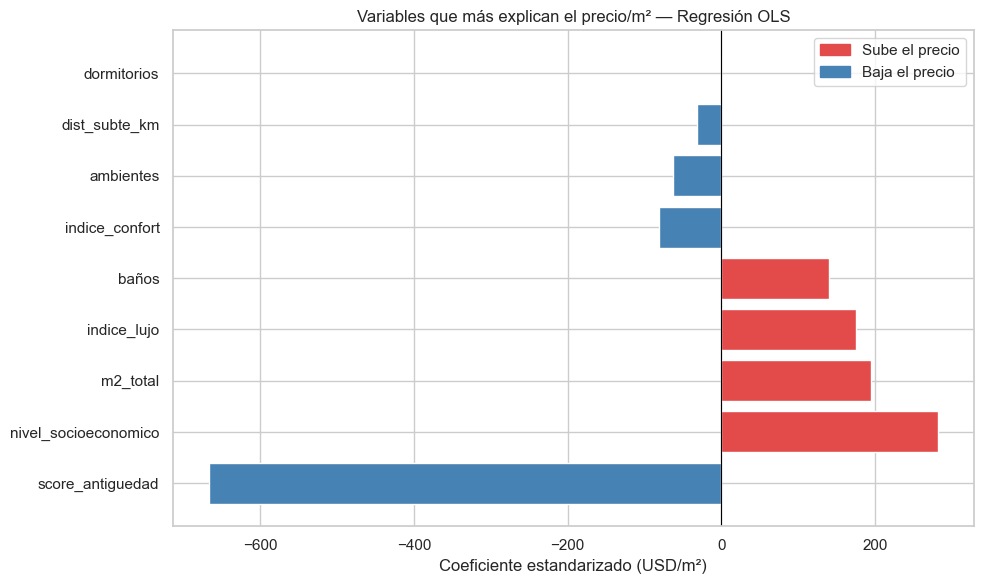

In [ ]:
# ── Coeficientes del mejor modelo lineal ─────────────────────────
# Usamos OLS para máxima interpretabilidad de coeficientes
pipe_ols = modelos_precio['OLS (sin regularización)']
coefs = pd.Series(
    pipe_ols.named_steps['model'].coef_,
    index=features_ok
).sort_values(key=abs, ascending=False)

print('\n=== Coeficientes OLS (estandarizados) ===')
print('Un coeficiente de X significa que, manteniendo el resto constante,')
print('esa variable mueve el precio/m² en X USD al variar 1 desvío estándar.\n')
print(coefs.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores_coef = ['#E24B4A' if c > 0 else 'steelblue' for c in coefs]
ax.barh(coefs.index, coefs.values, color=colores_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente estandarizado (USD/m²)')
ax.set_title('Variables que más explican el precio/m² — Regresión OLS')
patch_pos = mpatches.Patch(color='#E24B4A', label='Sube el precio')
patch_neg = mpatches.Patch(color='steelblue', label='Baja el precio')
ax.legend(handles=[patch_pos, patch_neg])
plt.tight_layout()
plt.show()

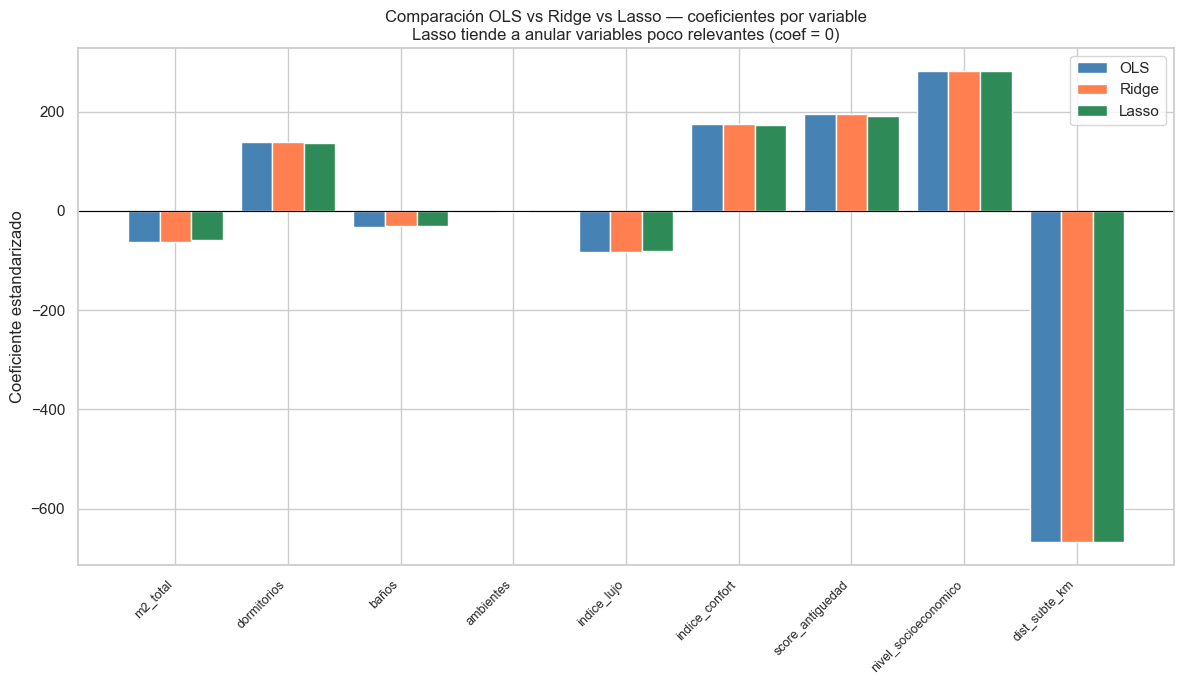


Variables anuladas por Lasso (coef = 0): ['dormitorios']
→ Estas variables no aportan poder explicativo adicional al precio/m².


In [ ]:
# ── Comparación visual OLS vs Lasso vs Ridge ──────────────────────
# Muestra qué features Lasso "apaga" (coef → 0)
coefs_lasso = pd.Series(
    modelos_precio['Lasso (L1)'].named_steps['model'].coef_,
    index=features_ok
)
coefs_ridge = pd.Series(
    modelos_precio['Ridge (L2)'].named_steps['model'].coef_,
    index=features_ok
)

df_coefs = pd.DataFrame({
    'OLS':   coefs,
    'Ridge': coefs_ridge,
    'Lasso': coefs_lasso,
})

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(features_ok))
width = 0.28
ax.bar(x - width, df_coefs['OLS'],   width, label='OLS',   color='steelblue', edgecolor='white')
ax.bar(x,         df_coefs['Ridge'], width, label='Ridge',  color='coral',     edgecolor='white')
ax.bar(x + width, df_coefs['Lasso'], width, label='Lasso',  color='seagreen',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(features_ok, rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Coeficiente estandarizado')
ax.set_title('Comparación OLS vs Ridge vs Lasso — coeficientes por variable\n'
             'Lasso tiende a anular variables poco relevantes (coef = 0)')
ax.legend()
plt.tight_layout()
plt.show()

lasso_nulos = coefs_lasso[coefs_lasso == 0].index.tolist()
print(f'\nVariables anuladas por Lasso (coef = 0): {lasso_nulos if lasso_nulos else "ninguna"}')
print('→ Estas variables no aportan poder explicativo adicional al precio/m².')

=== Árbol de decisión — precio/m² ===
R² test:  0.712
MAE test: 447.0 USD/m²


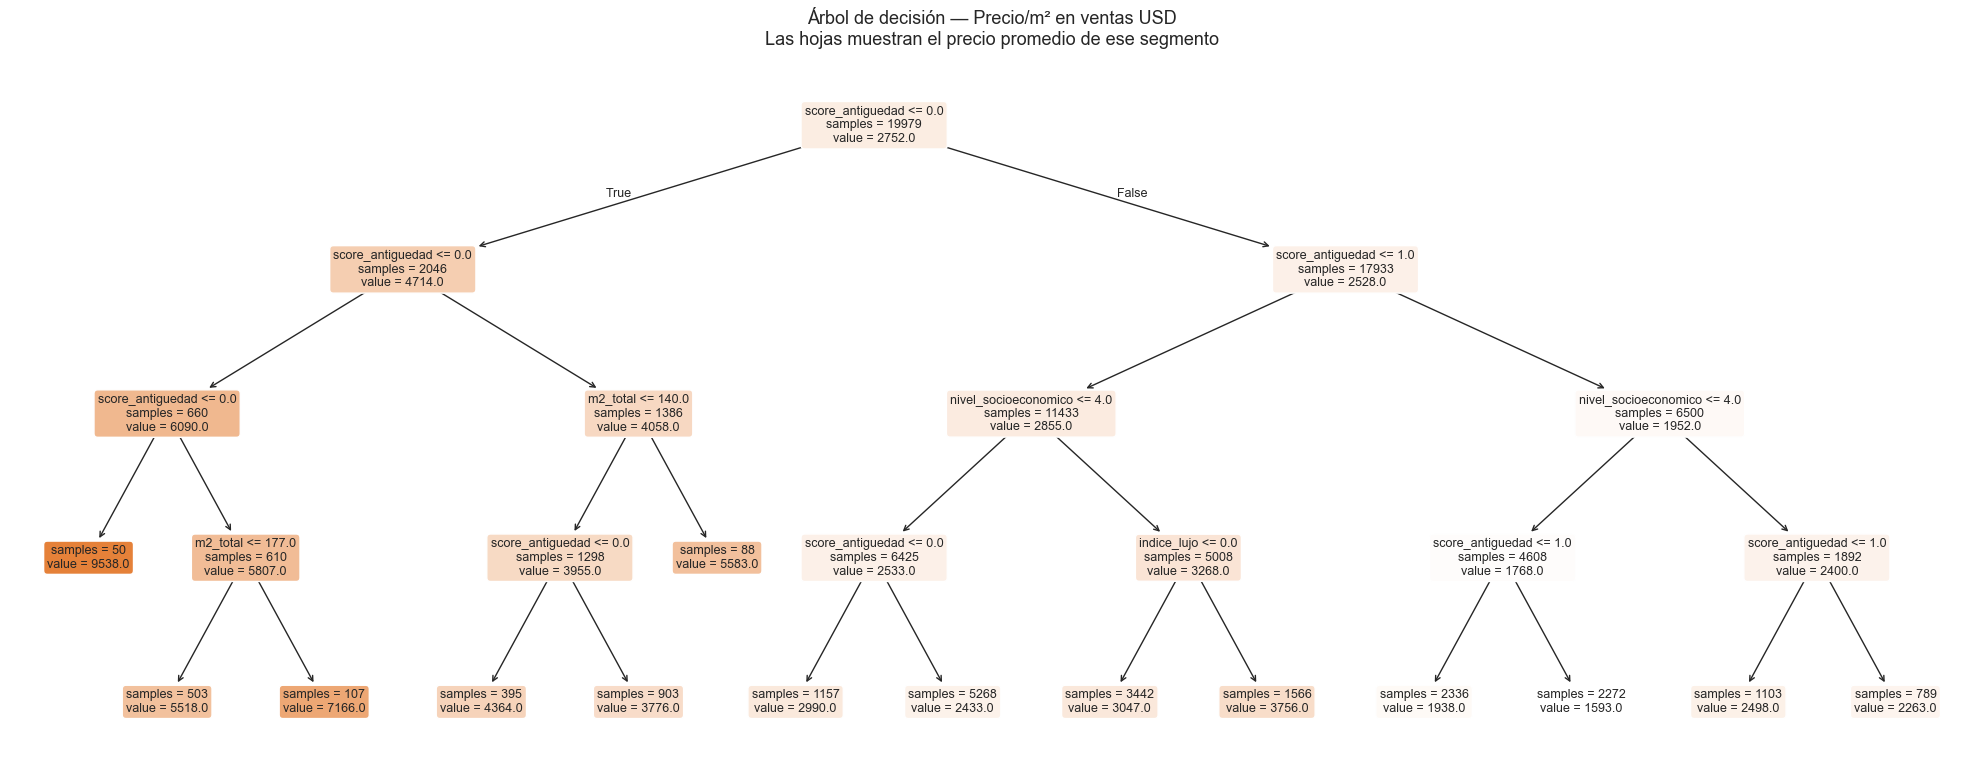

In [ ]:
# ── Árbol de decisión para precio ─────────────────────────────────
# Complementa la regresión: muestra reglas simples que el inversor puede leer

arbol_precio = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=50,
    random_state=SEED
)
arbol_precio.fit(X_train_p, y_train_p)

y_pred_arbol = arbol_precio.predict(X_test_p)
print('=== Árbol de decisión — precio/m² ===')
print(f'R² test:  {r2_score(y_test_p, y_pred_arbol):.3f}')
print(f'MAE test: {mean_absolute_error(y_test_p, y_pred_arbol):.1f} USD/m²')

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    arbol_precio,
    feature_names=features_ok,
    filled=True, rounded=True,
    fontsize=9, ax=ax,
    impurity=False, precision=0
)
ax.set_title('Árbol de decisión — Precio/m² en ventas USD\n'
             'Las hojas muestran el precio promedio de ese segmento', fontsize=13)
plt.tight_layout()
plt.show()

### 6.2 ¿Qué tipo de alquiler conviene? (target binario)
0 = largo plazo  
1 = temporario


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

# Verificación de que df_modal tiene datos y al menos dos clases
assert len(df_modal) >= 20, \
    f'df_modal tiene solo {len(df_modal)} filas. Revisá la celda 6.0.'

n_clases = df_modal['modalidad_optima'].nunique()
assert n_clases == 2, (
    f'modalidad_optima tiene solo {n_clases} valor(es) único(s): '
    f'{df_modal["modalidad_optima"].unique()}. '
    f'No es posible un modelo binario. Revisá los KPIs en df_kpis.'
)

X_m = df_modal[features_ok]
y_m = df_modal['modalidad_optima']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_m, y_m, test_size=0.2, random_state=SEED, stratify=y_m
)
print(f'Train: {len(X_train_m):,} | Test: {len(X_test_m):,}')
print(f'Clases en test → 0 (LP): {(y_test_m==0).sum()} | 1 (Temp): {(y_test_m==1).sum()}')

# ── Regresión Logística ──────────────────────────────────────────
pipe_logit = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=500, random_state=SEED, class_weight='balanced'))
])
pipe_logit.fit(X_train_m, y_train_m)
y_pred_logit  = pipe_logit.predict(X_test_m)
y_prob_logit  = pipe_logit.predict_proba(X_test_m)[:, 1]

print('\n=== Regresión Logística — ¿Temporario o Largo Plazo? ===')
print(classification_report(y_test_m, y_pred_logit,
      target_names=['Largo plazo', 'Temporario']))
print(f'AUC-ROC: {roc_auc_score(y_test_m, y_prob_logit):.3f}')

Train: 15,331 | Test: 3,833
Clases en test → 0 (LP): 3805 | 1 (Temp): 28

=== Regresión Logística — ¿Temporario o Largo Plazo? ===
              precision    recall  f1-score   support

 Largo plazo       1.00      0.96      0.98      3805
  Temporario       0.17      1.00      0.29        28

    accuracy                           0.96      3833
   macro avg       0.58      0.98      0.63      3833
weighted avg       0.99      0.96      0.98      3833

AUC-ROC: 0.986


=== Odds Ratios estandarizados — Regresión Logística ===
OR > 1 → la variable favorece elegir alquiler TEMPORARIO
OR < 1 → la variable favorece elegir LARGO PLAZO

dormitorios            1.589
dist_subte_km          1.263
baños                  1.094
indice_lujo            1.028
ambientes              0.938
m2_total               0.750
indice_confort         0.670
score_antiguedad       0.513
nivel_socioeconomico   0.003


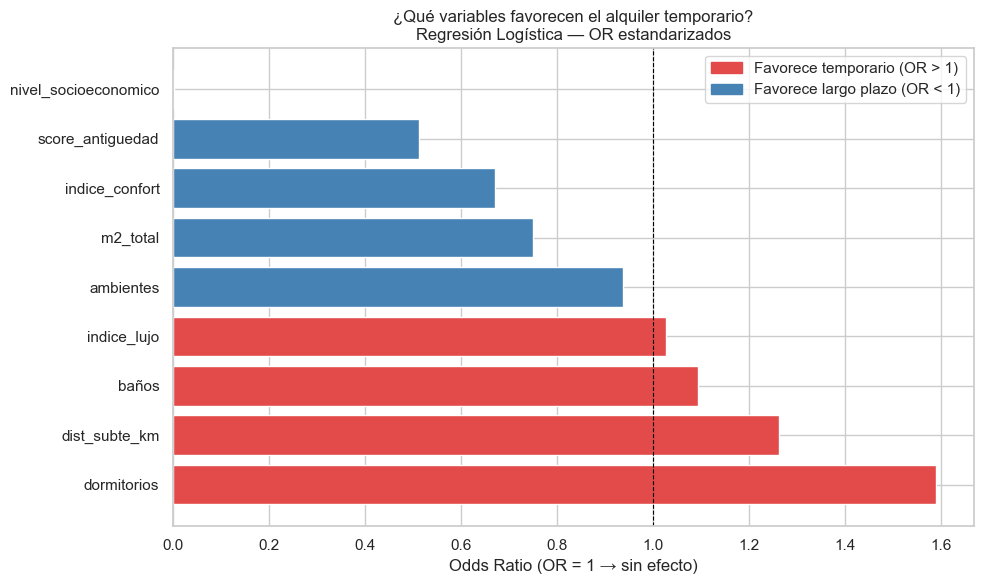


=== Árbol de Clasificación — Modalidad de alquiler ===
              precision    recall  f1-score   support

 Largo plazo       1.00      0.97      0.98      3805
  Temporario       0.20      1.00      0.33        28

    accuracy                           0.97      3833
   macro avg       0.60      0.98      0.66      3833
weighted avg       0.99      0.97      0.98      3833



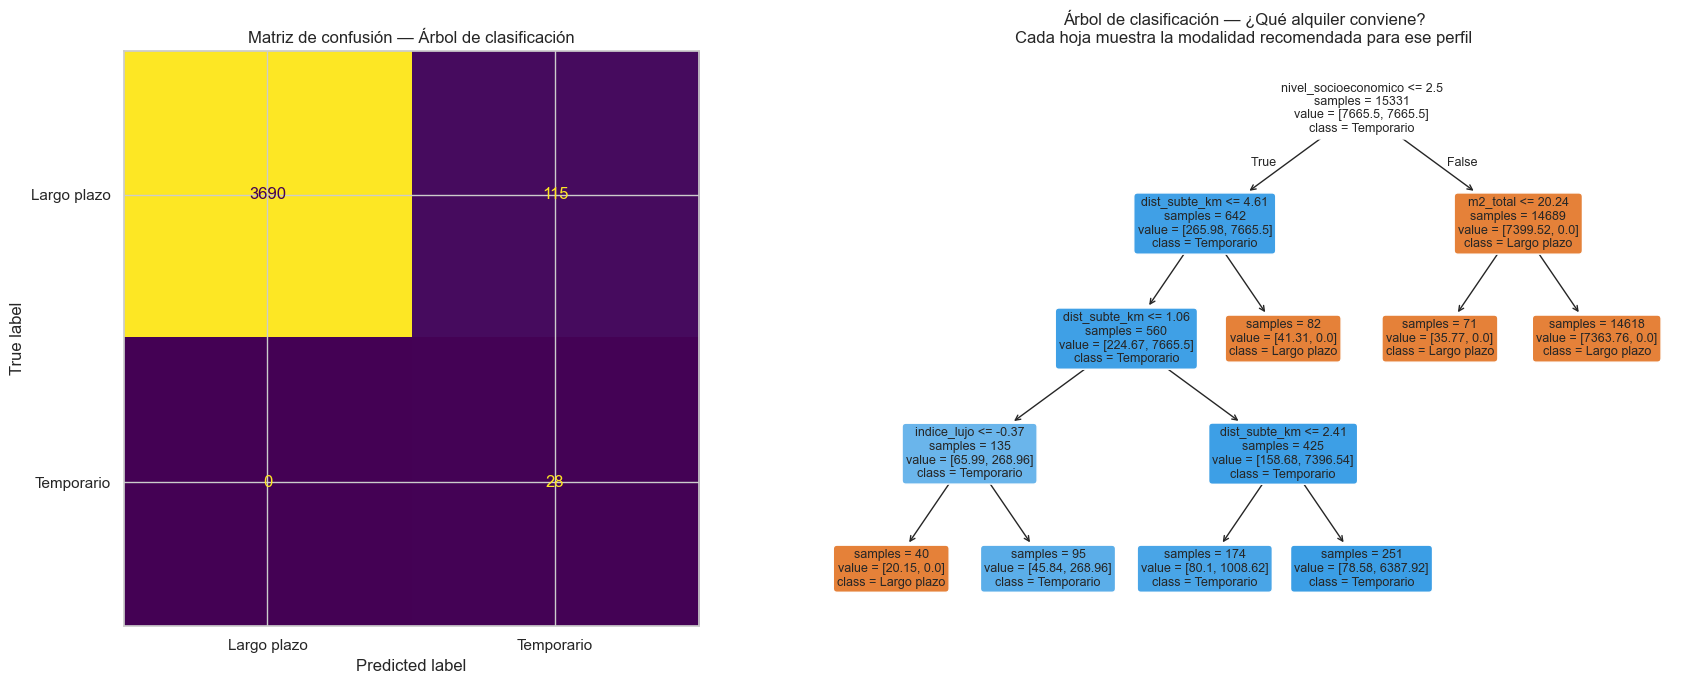

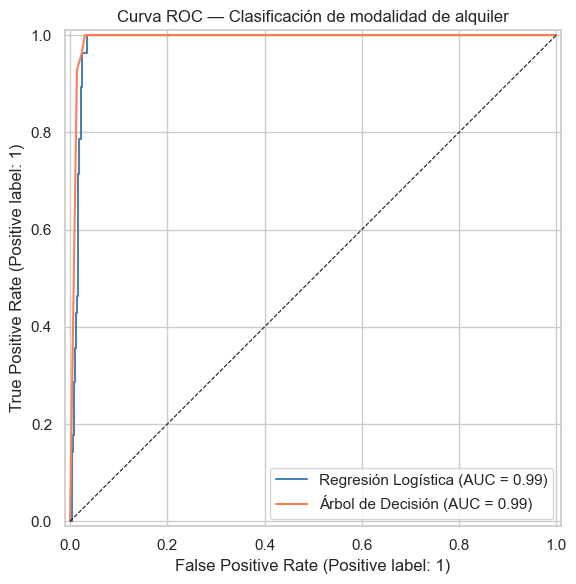

In [ ]:
# ── Odds ratios de la regresión logística ────────────────────────
# OR > 1 = la variable favorece el alquiler temporario
# OR < 1 = la variable favorece el largo plazo

coef_logit = pd.Series(
    pipe_logit.named_steps['model'].coef_[0],
    index=features_ok
)
odds_ratios = np.exp(coef_logit).sort_values(ascending=False)

print('=== Odds Ratios estandarizados — Regresión Logística ===')
print('OR > 1 → la variable favorece elegir alquiler TEMPORARIO')
print('OR < 1 → la variable favorece elegir LARGO PLAZO\n')
print(odds_ratios.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
colores_or = ['#E24B4A' if v > 1 else 'steelblue' for v in odds_ratios]
ax.barh(odds_ratios.index, odds_ratios.values, color=colores_or, edgecolor='white')
ax.axvline(1, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Odds Ratio (OR = 1 → sin efecto)')
ax.set_title('¿Qué variables favorecen el alquiler temporario?\n'
             'Regresión Logística — OR estandarizados')
patch_temp = mpatches.Patch(color='#E24B4A', label='Favorece temporario (OR > 1)')
patch_lp   = mpatches.Patch(color='steelblue', label='Favorece largo plazo (OR < 1)')
ax.legend(handles=[patch_temp, patch_lp])
plt.tight_layout()
plt.show()

# ── Árbol de clasificación ───────────────────────────────────────
arbol_modal = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=SEED,
    class_weight='balanced'
)
arbol_modal.fit(X_train_m, y_train_m)
y_pred_arbol_m  = arbol_modal.predict(X_test_m)
y_prob_arbol_m  = arbol_modal.predict_proba(X_test_m)[:, 1]

print('\n=== Árbol de Clasificación — Modalidad de alquiler ===')
print(classification_report(y_test_m, y_pred_arbol_m,
      target_names=['Largo plazo', 'Temporario']))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

cm = confusion_matrix(y_test_m, y_pred_arbol_m)
ConfusionMatrixDisplay(cm, display_labels=['Largo plazo', 'Temporario']).plot(
    ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión — Árbol de clasificación')

plot_tree(
    arbol_modal,
    feature_names=features_ok,
    class_names=['Largo plazo', 'Temporario'],
    filled=True, rounded=True,
    fontsize=9, ax=axes[1],
    impurity=False, precision=2
)
axes[1].set_title('Árbol de clasificación — ¿Qué alquiler conviene?\n'
                  'Cada hoja muestra la modalidad recomendada para ese perfil')
plt.tight_layout()
plt.show()

# ── Curva ROC comparativa ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test_m, y_prob_logit, name='Regresión Logística', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(
    y_test_m, y_prob_arbol_m, name='Árbol de Decisión', ax=ax, color='coral')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('Curva ROC — Clasificación de modalidad de alquiler')
plt.tight_layout()
plt.show()

=== Árbol de Clasificación — Modalidad de alquiler ===
              precision    recall  f1-score   support

 Largo plazo       1.00      0.97      0.98      3805
  Temporario       0.20      1.00      0.33        28

    accuracy                           0.97      3833
   macro avg       0.60      0.98      0.66      3833
weighted avg       0.99      0.97      0.98      3833



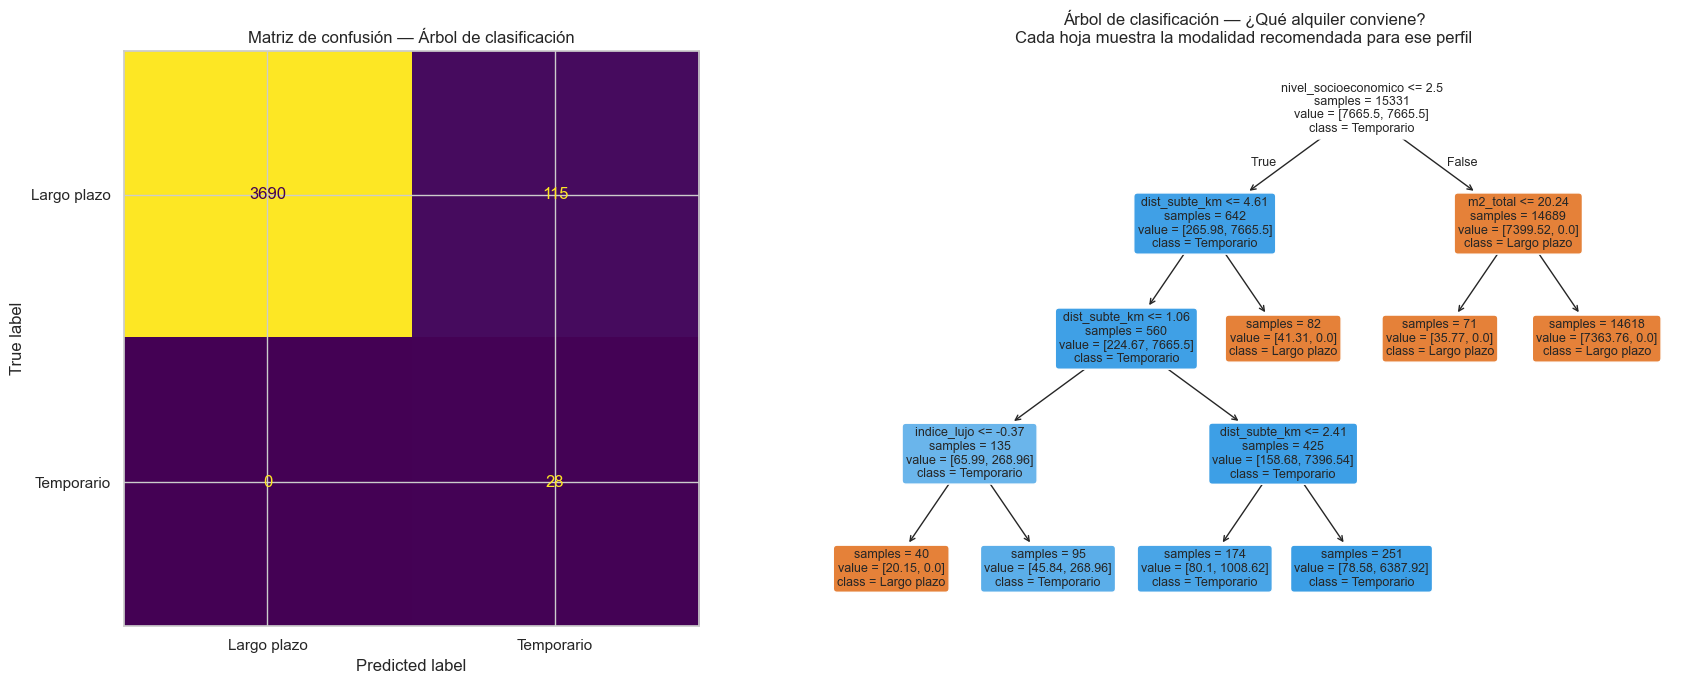

In [ ]:
# ── Árbol de clasificación ────────────────────────────────────────
arbol_modal = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    random_state=SEED,
    class_weight='balanced'
)
arbol_modal.fit(X_train_m, y_train_m)
y_pred_arbol_m = arbol_modal.predict(X_test_m)

print('=== Árbol de Clasificación — Modalidad de alquiler ===')
print(classification_report(y_test_m, y_pred_arbol_m,
      target_names=['Largo plazo', 'Temporario']))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de confusión
cm = confusion_matrix(y_test_m, y_pred_arbol_m)
ConfusionMatrixDisplay(cm, display_labels=['Largo plazo', 'Temporario']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión — Árbol de clasificación')

# Árbol
plot_tree(
    arbol_modal,
    feature_names=features_ok,
    class_names=['Largo plazo', 'Temporario'],
    filled=True, rounded=True,
    fontsize=9, ax=axes[1],
    impurity=False, precision=2
)
axes[1].set_title('Árbol de clasificación — ¿Qué alquiler conviene?\n'
                  'Cada hoja muestra la modalidad recomendada para ese perfil')
plt.tight_layout()
plt.show()

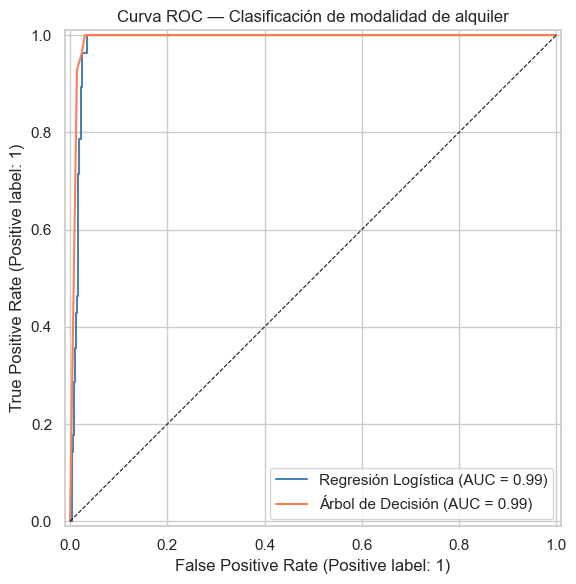

In [ ]:
# ── Curva ROC: logística vs árbol ────────────────────────────────
y_prob_arbol_m = arbol_modal.predict_proba(X_test_m)[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test_m, y_prob_logit,
    name='Regresión Logística', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test_m, y_prob_arbol_m,
    name='Árbol de Decisión', ax=ax, color='coral')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
ax.set_title('Curva ROC — Clasificación de modalidad de alquiler')
plt.tight_layout()
plt.show()

### 6.3 Importancia de variables y análisis de sensibilidad


=== Permutation Importance — Modelo de precio OLS ===
Caída de R² promedio al aleatorizar cada variable (20 repeticiones):
             feature  importancia_media  importancia_std
    score_antiguedad              0.671            0.012
nivel_socioeconomico              0.123            0.005
            m2_total              0.064            0.003
         indice_lujo              0.049            0.003
               baños              0.032            0.003
      indice_confort              0.009            0.001
           ambientes              0.004            0.001
       dist_subte_km              0.001            0.001
         dormitorios             -0.000            0.000


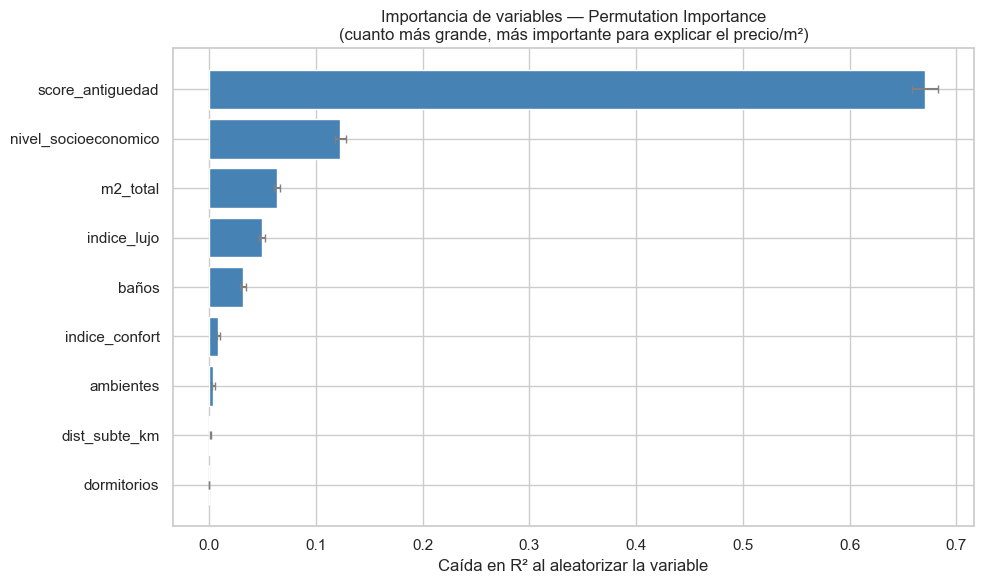

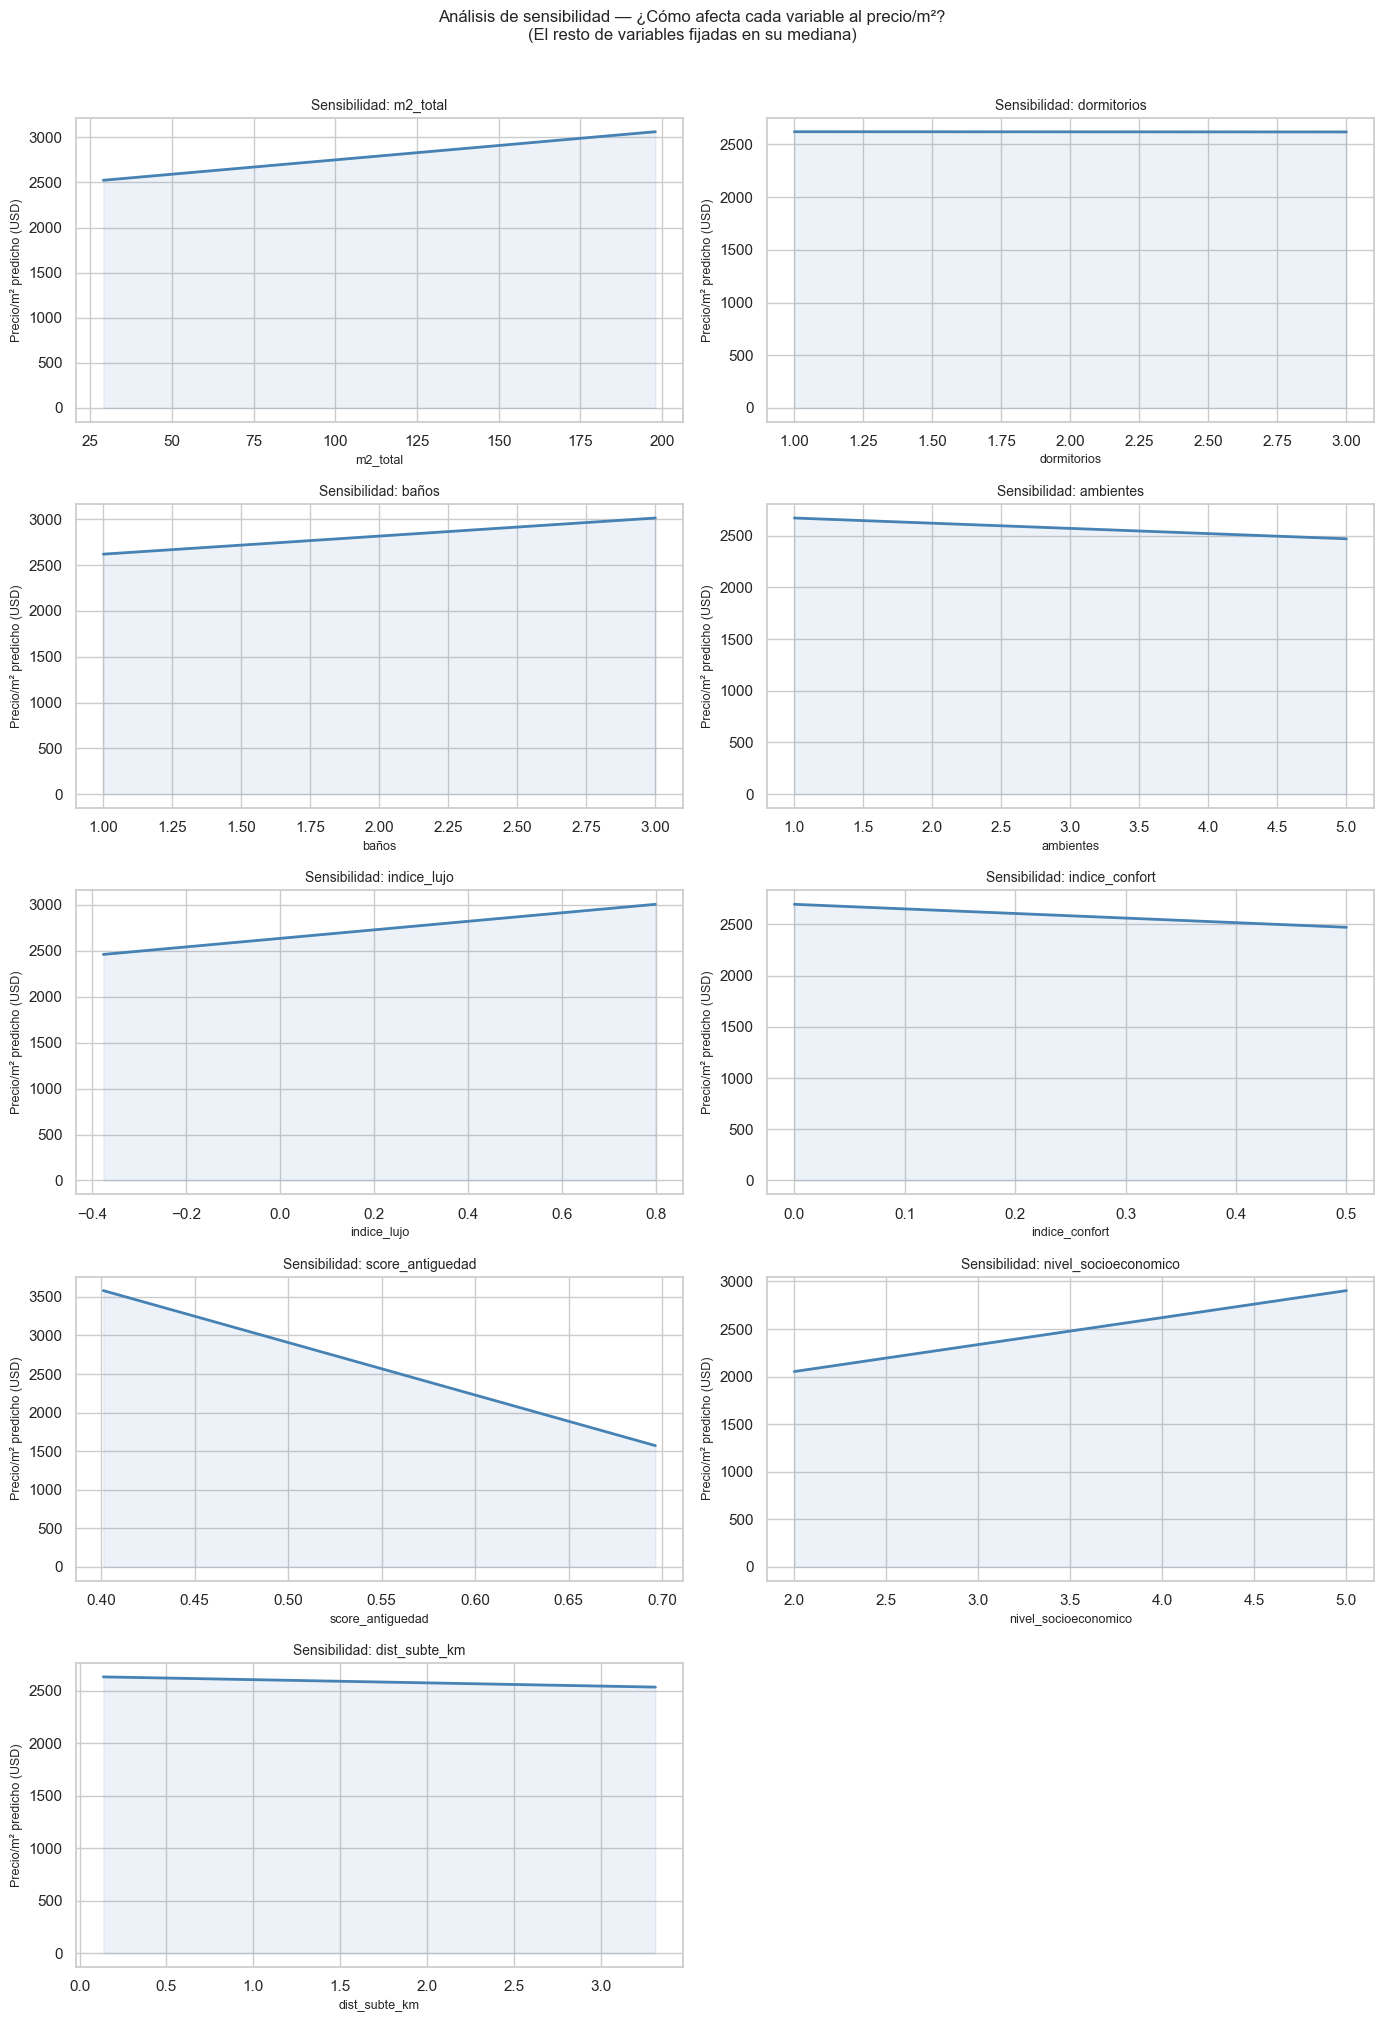

In [ ]:
# ── Permutation Importance ────────────────────────────────────────
# Mide cuánto cae el R² si aleatorizamos cada variable por separado.
# Es más confiable que leer los coeficientes directamente.

result_pi = permutation_importance(
    pipe_ols, X_test_p, y_test_p,
    n_repeats=20, random_state=SEED, scoring='r2'
)

importancias_pi = pd.DataFrame({
    'feature':           features_ok,
    'importancia_media': result_pi.importances_mean,
    'importancia_std':   result_pi.importances_std,
}).sort_values('importancia_media', ascending=False).reset_index(drop=True)

print('=== Permutation Importance — Modelo de precio OLS ===')
print('Caída de R² promedio al aleatorizar cada variable (20 repeticiones):')
print(importancias_pi.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importancias_pi['feature'][::-1],
    importancias_pi['importancia_media'][::-1],
    xerr=importancias_pi['importancia_std'][::-1],
    color='steelblue', edgecolor='white', ecolor='gray', capsize=3
)
ax.set_xlabel('Caída en R² al aleatorizar la variable')
ax.set_title('Importancia de variables — Permutation Importance\n'
             '(cuanto más grande, más importante para explicar el precio/m²)')
plt.tight_layout()
plt.show()

# ── Análisis de sensibilidad por variable continua ───────────────
# Para cada feature numérica, mostramos cómo cambia el precio predicho
# al recorrer su rango de P5 a P95 (manteniendo el resto fijo en su mediana)

fig, axes = plt.subplots(
    nrows=(len(features_ok) + 1) // 2, ncols=2,
    figsize=(14, 4 * ((len(features_ok) + 1) // 2))
)
axes = axes.flatten()

medianas_ref = X_test_p.median()

for i, feat in enumerate(features_ok):
    rango = np.linspace(
        df_precio[feat].quantile(0.05),
        df_precio[feat].quantile(0.95),
        50
    )
    predicciones = []
    for val in rango:
        X_tmp = pd.DataFrame([medianas_ref] * 50, columns=features_ok)
        X_tmp[feat] = val
        predicciones.append(pipe_ols.predict(X_tmp).mean())

    axes[i].plot(rango, predicciones, color='steelblue', linewidth=2)
    axes[i].fill_between(rango, predicciones, alpha=0.1, color='steelblue')
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Precio/m² predicho (USD)', fontsize=9)
    axes[i].set_title(f'Sensibilidad: {feat}', fontsize=10)

# Ocultamos los subplots vacíos si el número de features es impar
for j in range(len(features_ok), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Análisis de sensibilidad — ¿Cómo afecta cada variable al precio/m²?\n'
             '(El resto de variables fijadas en su mediana)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

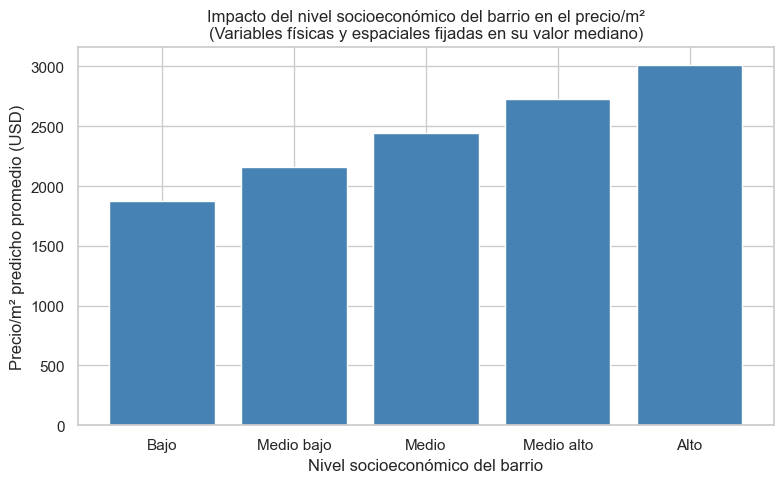

In [ ]:
# ── Sensibilidad al nivel socioeconómico ──────────────────────────
if 'nivel_socioeconomico' in features_ok:
    niveles = sorted(df_precio['nivel_socioeconomico'].dropna().unique())
    precios_nse = []
    for nse in niveles:
        X_tmp = X_test_p.copy()
        X_tmp['nivel_socioeconomico'] = nse
        precios_nse.append(pipe_ols.predict(X_tmp).mean())

    fig, ax = plt.subplots(figsize=(8, 5))
    etiquetas_nse = {1: 'Bajo', 2: 'Medio bajo', 3: 'Medio',
                     4: 'Medio alto', 5: 'Alto'}
    ax.bar(
        [etiquetas_nse.get(int(n), str(n)) for n in niveles],
        precios_nse,
        color='steelblue', edgecolor='white'
    )
    ax.set_xlabel('Nivel socioeconómico del barrio')
    ax.set_ylabel('Precio/m² predicho promedio (USD)')
    ax.set_title('Impacto del nivel socioeconómico del barrio en el precio/m²\n'
                 '(Variables físicas y espaciales fijadas en su valor mediano)')
    plt.tight_layout()
    plt.show()

### 6.4 Recomendación integrada para el inversor principiante

In [ ]:
# ── 6.4 Recomendación integrada para el inversor ─────────────────
# Esta sección funciona con o sin cluster_nombre.
# Si el clustering de la sección 5 corrió bien, agrega esa dimensión.

kpis_rec = df_kpis.set_index('barrio_oficial') if 'barrio_oficial' in df_kpis.columns \
           else df_kpis.copy()

kpis_rec = kpis_rec[['rent_neta_lp_pct', 'rent_neta_temp_pct', 'precio_m2_mediano']].copy()
kpis_rec = kpis_rec.dropna(subset=['rent_neta_lp_pct', 'rent_neta_temp_pct'])

kpis_rec['modalidad_sugerida'] = np.where(
    kpis_rec['rent_neta_temp_pct'] > kpis_rec['rent_neta_lp_pct'],
    'Temporario', 'Largo Plazo'
)
kpis_rec['ventaja_temp_pp'] = (
    kpis_rec['rent_neta_temp_pct'] - kpis_rec['rent_neta_lp_pct']
).round(2)

# Agregamos cluster si está disponible
if 'cluster_nombre' in df.columns:
    cluster_por_barrio_rec = (
        df.dropna(subset=['cluster_nombre'])
        .groupby('barrio_oficial')['cluster_nombre']
        .agg(lambda s: s.mode().iloc[0])
    )
    kpis_rec['cluster'] = kpis_rec.index.map(cluster_por_barrio_rec)
else:
    print('ℹ️  cluster_nombre no disponible (sección 5 no corrió). '
          'La tabla se muestra sin columna de cluster.')
    kpis_rec['cluster'] = 'n/d'

tabla_rec = kpis_rec.sort_values('rent_neta_temp_pct', ascending=False)

print('=== Tabla de recomendación por barrio ===')
print('Ordenada por rentabilidad neta temporaria\n')
print(tabla_rec.to_string())

print('\n── Top 5 barrios para ALQUILER TEMPORARIO ──')
top_temp = tabla_rec[tabla_rec['modalidad_sugerida'] == 'Temporario'].head(5)
print(top_temp[['rent_neta_temp_pct', 'precio_m2_mediano', 'cluster']].to_string())

print('\n── Top 5 barrios para LARGO PLAZO ──')
top_lp = (tabla_rec[tabla_rec['modalidad_sugerida'] == 'Largo Plazo']
          .sort_values('rent_neta_lp_pct', ascending=False)
          .head(5))
print(top_lp[['rent_neta_lp_pct', 'precio_m2_mediano', 'cluster']].to_string())

ℹ️  cluster_nombre no disponible (sección 5 no corrió). La tabla se muestra sin columna de cluster.
=== Tabla de recomendación por barrio ===
Ordenada por rentabilidad neta temporaria

                   rent_neta_lp_pct  rent_neta_temp_pct  precio_m2_mediano modalidad_sugerida  ventaja_temp_pp cluster
barrio_oficial                                                                                                        
Nueva Pompeya                     7               9.000          1,333.000         Temporario            2.000     n/d
Villa Luro                        5               9.000          2,414.000         Temporario            4.000     n/d
Parque Avellaneda                 7               7.000          1,613.000        Largo Plazo            0.000     n/d
La Boca                           7               6.000          1,393.000        Largo Plazo           -1.000     n/d
Monserrat                         7               5.000          1,829.000        Largo Plazo        